# Figure 5,帮助找到最佳传感器组合

* 用 Syn & Syn/ΔEnergy 从单体出发筛出“值得加的那一个”；
* 把这些候选放进 LCB–帕累托，在你的约束下（能量/质量/价格）选最终解。VT这能同时兼顾“局部增益”与“全局可行性”。


In [1]:
import pandas as pd
# from itertools import combinations
import matplotlib.pyplot as plt
# import os
import numpy as np

# —— 复用你项目中的数据/模型工具（保持接口一致） ——
from deepview.calculate_results.models.utils import (
    sensor_list_to_tag,
    read_sensor_data,
)

import os
import copy
import pickle
# import numpy as np
import torch
# import pandas as pd
from itertools import combinations
# import matplotlib as plt
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split

# —— 复用你项目中的数据/模型工具（保持接口一致） ——
from deepview.calculate_results.models.utils import (
    data_loader_umineko,
    majority_value,
    sliding_window,
    process_sensors,
    sensor_list_to_tag,
    # read_sensor_data,
)

# from deepview.calculate_results.data.omizunagidori.active_supContrast import read_sensor_data
from deepview.calculate_results.data.umineko.model_func import get_model_for_sensors
from deepview.calculate_results.data.umineko.train_func import evaluate_model
from sklearn.metrics import precision_recall_fscore_support
 
# -------------------------------
# 1) Sensor cost/specs (editable)
# -------------------------------
sensors = ["ACC","GYRO","MAG","TEMP","PRES","ILLU","GPS"]



sensor_specs = pd.DataFrame([
    {"sensor":"ACC",   "energy_mAh_per_day":0.35, "mass_g":0.135, "price_usd":2.5,  "volume_mm3":4.0},
    {"sensor":"GYRO",  "energy_mAh_per_day":20.0, "mass_g":0.098, "price_usd":4.5,  "volume_mm3":6.0},
    {"sensor":"MAG",   "energy_mAh_per_day":0.96, "mass_g":0.078, "price_usd":5.0,  "volume_mm3":4.0},
    {"sensor":"TEMP",  "energy_mAh_per_day":0.084,"mass_g":0.012, "price_usd":3.0,  "volume_mm3":3.0},
    {"sensor":"PRES",  "energy_mAh_per_day":0.077,"mass_g":0.015, "price_usd":3.1,  "volume_mm3":3.0},
    {"sensor":"ILLU", "energy_mAh_per_day":0.060,"mass_g":0.008, "price_usd":2.6,  "volume_mm3":2.6},
    {"sensor":"GPS",   "energy_mAh_per_day":168.0,"mass_g":0.500, "price_usd":22.0, "volume_mm3":245.0},
])



bird = 'umineko'  # 'umineko' or 'omizunagidori'
if bird=='umineko':
    from deepview.calculate_results.models.utils import read_sensor_data
    root_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko'
elif bird=='omizunagidori':
    from deepview.calculate_results.data.omizunagidori.active_supContrast import read_sensor_data
    root_path = r'D:\code\DeepView\deepview\calculate_results\data\omizunagidori'
else:
    print('error, other animals')
    
# ----------------------------
# 2) Simulate 5-run F1s
#    (replace with real numbers if available)
# ----------------------------
n_rep = 5
z_095 = 1.645


## parameter setting

In [2]:
def sum_costs(senl):
    E = M = P = V = 0.0
    for s in senl:
        E += cost_map[s]["energy_mAh_per_day"]
        M += cost_map[s]["mass_g"]
        P += cost_map[s]["price_usd"]
        V += cost_map[s]["volume_mm3"]
    return E, M, P, V



In [10]:

WEIGHTS_PATH = None                 # 或者指定模型权重文件 .pt/.pth；若设置了此项，将忽略 RESULTS_PKL
WEIGHT_IDX = -1                     # 从 results.pkl 的 weight_list 里取第几个（-1 表示最后一个）
LEN_SW = 50                         # 滑窗长度，需与训练一致
TEST_SIZE = 0.2                     # 测试集比例
SEED = 42                           # train_test_split 的随机种子（与训练保持一致）
DEVICE = "cuda:1"                   # 自动：'cuda:0' if torch.cuda.is_available() else 'cpu'


def load_multiple_pickles(path):
    """读取由多次 pickle.dump 组成的 pkl，合并为同一个 dict。"""
    merged = {}
    with open(path, "rb") as f:
        while True:
            try:
                obj = pickle.load(f)
                if isinstance(obj, dict):
                    merged.update(obj)
            except EOFError:
                break
    return merged


def build_dataset_for_sensors(sensor_type, len_sw=LEN_SW, compute_gps=True):
    """
    与训练一致的数据构造：
    - 若缓存 {tag}_data.npz 存在则直接读；
    - 否则 read_sensor_data -> process_sensors -> sliding_window，并缓存。
    输出形状 [B, C, T]，label_b 为 [B, T]（与你训练脚本一致的转置约定）。 
    """
    tag = sensor_list_to_tag(sensor_type, compute_gps=compute_gps)
    # cache_path = f"{tag}_data.npz"
    cache_path = os.path.join(root_path, f"{tag}_data.npz")

    if os.path.exists(cache_path):
        with np.load(cache_path, allow_pickle=False) as f:
            data_b = f["data"]
            label_b = f["label"]
    else:
        all_df = read_sensor_data()
        selected_df = all_df[all_df.label_id != -2]
        selected_np, _ = process_sensors(selected_df, sensor_type)

        tmp_b = sliding_window(selected_np, len_sw, len_sw)
        data_b = np.transpose(tmp_b[:, :, :-1], (0, 2, 1))  # [B, Len, dim-1] -> [B, dim-1, Len]
        label_b = tmp_b[:, :, -1]
        np.savez_compressed(cache_path, data=data_b.astype(np.float32), label=label_b)

    return data_b, label_b, tag


def stratified_train_test_split(data_b, label_b, test_size=TEST_SIZE, seed=SEED):
    """
    用多数投票标签 vote_label 做分层切分（与训练保持一致）。
    """
    vote_label = majority_value(label_b)
    X_train, X_test, y_train, y_test = train_test_split(
        data_b,
        label_b,
        test_size=test_size,
        stratify=vote_label,
        random_state=seed,
    )
    return X_train, X_test, y_train, y_test


def build_model(sensor_type, num_classes, state_dict=None, weights_path=None, device=DEVICE):
    """
    构建并加载权重：
    - 优先 weights_path 的 .pt/.pth
    - 否则使用传入的 state_dict
    """
    model = get_model_for_sensors(sensor_type, number_classes=num_classes)
    model = model.to(device)

    if weights_path is not None:
        ckpt = torch.load(weights_path, map_location=device)
        if isinstance(ckpt, dict) and "state_dict" in ckpt:
            model.load_state_dict(ckpt["state_dict"])
        elif isinstance(ckpt, dict):
            model.load_state_dict(ckpt)
        else:
            raise ValueError("Unrecognized checkpoint format for weights_path.")
    elif state_dict is not None:
        model.load_state_dict(state_dict)
    else:
        raise ValueError("Either 'state_dict' or 'weights_path' must be provided.")

    model.eval()
    return model


def build_loader(X, y, device=DEVICE, batch_size=4000):
    """
    与训练一致的数据封装到 data_loader_umineko，再用 DataLoader 包装。
    """
    major_y = majority_value(y)
    ds = data_loader_umineko(X.astype(float), major_y.astype(int), y.astype(int), device=device)
    return DataLoader(ds, batch_size=batch_size, shuffle=False, drop_last=False)


def run_eval(RESULTS_PKL, SENSORS):
    # 1) 规范化传感器列表
    sensor_type = [s.strip() for s in SENSORS] if isinstance(SENSORS, (list, tuple)) else [str(SENSORS)]

    # 2) 构造数据
    data_b, label_b, tag = build_dataset_for_sensors(sensor_type, len_sw=LEN_SW)
    print(np.unique(label_b))
    # 3) 切分（分层、随机种子与训练保持一致）
    X_train, X_test, y_train, y_test = stratified_train_test_split(data_b, label_b, test_size=TEST_SIZE, seed=SEED)

    # 4) 准备权重
    state_dict = None
    if WEIGHTS_PATH is None:
        if RESULTS_PKL is None:
            raise ValueError("请至少提供 RESULTS_PKL 或 WEIGHTS_PATH 其中之一。")
        merged = load_multiple_pickles(RESULTS_PKL)
        if "weight_list" not in merged or len(merged["weight_list"]) == 0:
            raise ValueError(f"'weight_list' 不存在或为空：{RESULTS_PKL}")
        state_dict = copy.deepcopy(merged["weight_list"][WEIGHT_IDX])

    # 5) 构建模型并加载权重
    num_classes = int(np.max(label_b) + 1)
    print(num_classes)
    model = build_model(sensor_type, num_classes, state_dict=state_dict, weights_path=WEIGHTS_PATH, device=DEVICE)

    # 6) 评估（与你训练中 evaluate_model 的返回保持一致）
    test_loader = build_loader(X_test, y_test, device=DEVICE, batch_size=4000)
    accuracy, macro_f1, micro_f1, pred_list, truth_list = evaluate_model(model, test_loader, DEVICE)

    return macro_f1, micro_f1


In [7]:
num_classes

NameError: name 'num_classes' is not defined

In [4]:
tag2sensor = {
    'acc':'ACC',
    'tmp':'TEMP',
    'gpsbv':'GPS',
    'prs': 'PRES',
    'gyr': 'GYRO',
    'mag':'MAG',
    'illum':'ILLU',
    
    'acc_tmp':'ACC+TEMP',
    'acc_gpsbv':'ACC+GPS',
    'acc_gyr':'ACC+GYRO',
    'acc_prs':'ACC+PRES',
    'acc_mag':'ACC+MAG',
    'acc_illum':'ACC+ILLU',
    
    'prs_tmp':'PRES+TEMP',
    'prs_gpsbv':'PRES+GPS',
    'prs_illum':'PRES+ILLU',
    
    'gyr_gpsbv':'GYRO+GPS',
    'gyr_mag':'GYRO+MAG',
    'gyr_illum':'GYRO+ILLU',
    'gyr_tmp':'GYRO+TEMP',
    'gyr_prs':'GYRO+PRES',
    
    'mag_illum':'MAG+ILLU',
    'mag_prs':'MAG+PRES',
    'mag_tmp':'MAG+TEMP',
    'mag_gpsbv':'MAG+GPS',
    
    'tmp_gpsbv':'TEMP+GPS',
    'tmp_illum':'TEMP+ILLU',
    
    'gpsbv_illum':'GPS+ILLU',
    
    'prs_tmp_illum':'PRES+TEMP+ILLU',
    'prs_tmp_gpsbv_illum':'PRES+TEMP+GPS+ILLU',
    'prs_tmp_illum_gpsbv':'PRES+TEMP+ILLU+GPS',
    
    'mag_prs_tmp_illum':'MAG+PRES+TEMP+ILLU',
    'mag_prs_illum':'MAG+PRES+ILLU',
    'mag_prs_tmp':'MAG+PRES+TEMP',
    'mag_illum_tmp':'MAG+ILLU+TEMP',
    'mag_illum_prs':'MAG+ILLU+PRES',
    'mag_tmp_illum':'MAG+TEMP+ILLU',
}

## calculate multiple sensor combos (Syn_LCB)

In [5]:
## 选择传感器类型
sensor_list=["Accel", "GPS", "Press", "Mag", "Gyro", "Illum", "Temp"]
pair_list = [list(p) for p in combinations(sensor_list, 2)]
sensor_list = [[s] for s in sensor_list]
all_sensor_list = sensor_list + pair_list
# all_sensor_list

# root_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko'

##### 计算所有凉凉组合的supervised F1

In [11]:
raw_map = {}   # sen_tag -> list of micro-F1
summary, summary_full = [], []   # [(sen_tag, mean, var, std), ...]
all_tags = []
means, stds = [], []
for Sen in all_sensor_list:
    vals = []
    tag = sensor_list_to_tag(Sen, compute_gps=True)  # compute_gps 来自你的管线配置
    for i in range(5):
        seed_value=30+i  # i 为第几个实验
        name_label = '_supervisebase_seed%s' % str(seed_value)
        res_PKL = os.path.join(root_path, tag+'_%s_epoch%s_results.pkl'%(name_label, str(50)))  # 若用 pkl 中的权重
        macro_f1, micro_f1 = run_eval(res_PKL, Sen)
        vals.append(float(micro_f1))
    raw_map[tag] = vals

    m = float(np.mean(vals))
    v = float(np.var(vals, ddof=1))   # 样本方差
    s = float(np.std(vals, ddof=1))   # 样本标准差
    summary.append((tag, m, v, s))  # 作条形图
    summary_full.append((tag, vals))
    all_tags.append(tag)
    means.append(m)
    stds.append(s)


[0. 1. 2. 3. 4. 5.]


D:\Users\dell\anaconda3\envs\deepviewbackup\lib\site-packages\torch\storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


6


RuntimeError: Error(s) in loading state_dict for MultiSensorFusionNN:
	size mismatch for classifier.4.weight: copying a param with shape torch.Size([5, 32]) from checkpoint, the shape in current model is torch.Size([6, 32]).
	size mismatch for classifier.4.bias: copying a param with shape torch.Size([5]) from checkpoint, the shape in current model is torch.Size([6]).

In [28]:


rows = []
count = 1
for s_info in summary_full:
    s = tag2sensor[s_info[0]]
    # print(f"{s}: {s_info[1]}")
    # print(s_info[1])
    rows.append({"combo_id": str(count), "sensors": s, "F1_run1":s_info[1][0], "F1_run2":s_info[1][1], "F1_run3":s_info[1][2], "F1_run4":s_info[1][3], "F1_run5":s_info[1][4]})
    count += 1

perf_df = pd.DataFrame(rows, columns=["combo_id","sensors","F1_run1","F1_run2","F1_run3","F1_run4","F1_run5"])


cost_map = sensor_specs.set_index("sensor")[["energy_mAh_per_day","mass_g","price_usd","volume_mm3"]].to_dict("index")


records = []
for _, r in perf_df.iterrows():
    if r["sensors"] == "ALL":
        sensor_list = ['ACC', 'GYRO', 'MAG', 'TEMP', 'ILLU', 'PRES', 'GPS']
    else:
        sensor_list = r["sensors"].split("+")
    E, M, P, V = sum_costs(sensor_list)
    runs = np.array([r[f"F1_run{i+1}"] for i in range(n_rep)], dtype=float)
    fbar = runs.mean()
    s = runs.std(ddof=1)
    lcb = float(fbar - z_095*s/np.sqrt(n_rep))
    records.append({
        "combo_id": r["combo_id"],
        "sensors": r["sensors"],
        "Energy_mAh_per_day": E,
        "Mass_g": M,
        "Price_usd": P,
        "Volume_mm3": V,
        "Fbar": fbar,
        "Std": s,
        "LCB95": lcb,
        "n_rep": n_rep
    })
res_df = pd.DataFrame(records)


In [29]:
# 含不含 '+' 的布尔掩码
has_plus = res_df["sensors"].str.contains(r"\+", na=False)

# 拆成两个 DataFrame
single_dfu = res_df[~has_plus].copy()  # 没有 '+' 的（单体）
pair_dfu   = res_df[ has_plus].copy()  # 其余（包含 '+' 的组合）

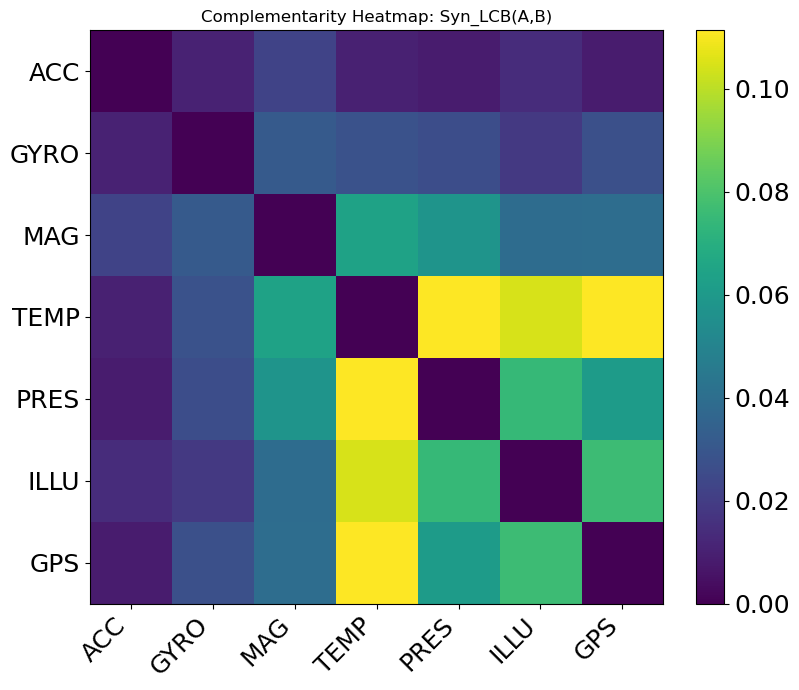

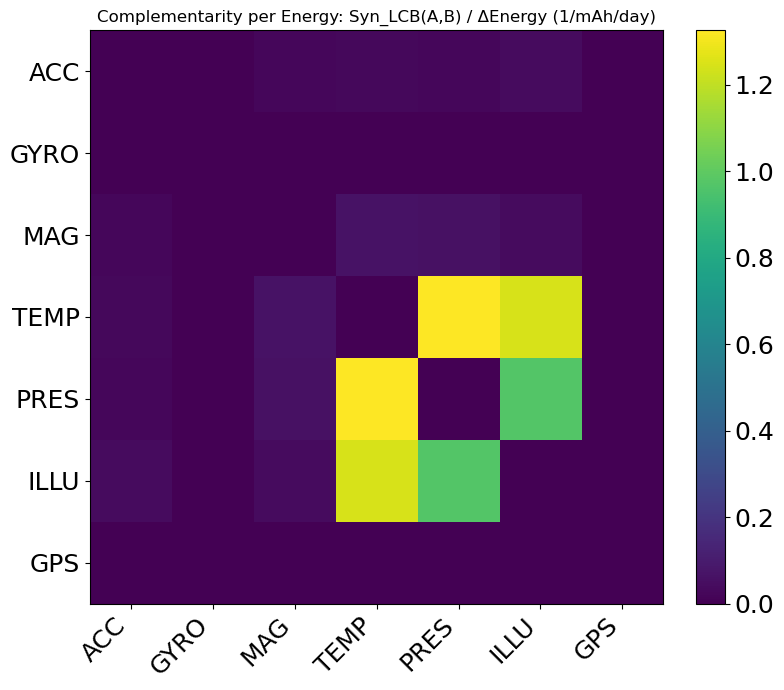

In [30]:
# ----------------------------
# 3) Compute Syn_LCB matrix
# ----------------------------
# Align lookup tables
single_lcb = dict(zip(single_dfu["sensors"], single_dfu["LCB95"]))
pair_lcb = {tuple(sorted(p["sensors"].split("+"))): p["LCB95"] for _, p in pair_dfu.iterrows()}

syn_mat = np.full((len(sensors), len(sensors)), np.nan, dtype=float)
for i,a in enumerate(sensors):
    for j,b in enumerate(sensors):
        if i == j:
            syn_mat[i,j] = 0.0
        else:
            key = tuple(sorted([a,b]))
            lcb_ab = pair_lcb.get(key, np.nan)
            base_ab = max(single_lcb[a], single_lcb[b])
            syn = lcb_ab - base_ab if not np.isnan(lcb_ab) else np.nan
            syn_mat[i,j] = syn

syn_df = pd.DataFrame(syn_mat, index=sensors, columns=sensors)

# (Optional) Syn per added energy (cost-normalized)
cost_map = sensor_specs.set_index("sensor")[["energy_mAh_per_day","mass_g","price_usd","volume_mm3"]].to_dict("index")
def added_energy(a,b):
    return cost_map[a]["energy_mAh_per_day"] + cost_map[b]["energy_mAh_per_day"] - min(cost_map[a]["energy_mAh_per_day"], cost_map[b]["energy_mAh_per_day"])
# simpler: just sum(a)+sum(b) - max(single) doesn't make sense; we want incremental over best single for fair "add one" scenario
# We'll compute ΔE relative to the better (lower energy) single by default:
def delta_energy_over_best_single(a,b):
    Ea, Eb = cost_map[a]["energy_mAh_per_day"], cost_map[b]["energy_mAh_per_day"]
    # when you "upgrade" from the cheaper-energy single to pair(a,b), ΔE is the energy of the other one
    return max(Ea, Eb)

syn_per_mAh = np.zeros_like(syn_mat, dtype=float)
for i,a in enumerate(sensors):
    for j,b in enumerate(sensors):
        if i == j:
            syn_per_mAh[i,j] = 0.0
        else:
            dE = delta_energy_over_best_single(a,b)
            syn_per_mAh[i,j] = syn_mat[i,j]/dE if dE>0 else np.nan
syn_per_mAh_df = pd.DataFrame(syn_per_mAh, index=sensors, columns=sensors)

# ----------------------------
# 4) Heatmap (matplotlib; no seaborn; one chart per figure)
# ----------------------------
fig1 = plt.figure(figsize=(9,7))
ax1 = fig1.add_subplot(111)
im1 = ax1.imshow(syn_mat, interpolation='nearest')
ax1.set_xticks(range(len(sensors)))
ax1.set_yticks(range(len(sensors)))
ax1.set_xticklabels(sensors, rotation=45, ha="right")
ax1.set_yticklabels(sensors)
ax1.set_title("Complementarity Heatmap: Syn_LCB(A,B)")
# fig1.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
# 放大坐标轴刻度整体字号
ax1.tick_params(axis='both', labelsize=18)
# 放大colorbar刻度
cbar = fig1.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=18)
fig1.tight_layout()


# fig_path1 = "/mnt/data/syn_heatmap.png"
# plt.savefig(fig_path1, dpi=180, bbox_inches="tight")
# plt.show()

fig2 = plt.figure(figsize=(9,7))
ax2 = fig2.add_subplot(111)
im2 = ax2.imshow(syn_per_mAh, interpolation='nearest')
ax2.set_xticks(range(len(sensors)))
ax2.set_yticks(range(len(sensors)))
ax2.set_xticklabels(sensors, rotation=45, ha="right")
ax2.set_yticklabels(sensors)
ax2.set_title("Complementarity per Energy: Syn_LCB(A,B) / ΔEnergy (1/mAh/day)")

# 放大坐标轴刻度整体字号
ax2.tick_params(axis='both', labelsize=18)
# 放大colorbar刻度
cbar = fig2.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=18)
fig2.tight_layout()
# fig_path2 = "/mnt/data/syn_per_energy_heatmap.png"
# plt.savefig(fig_path2, dpi=180, bbox_inches="tight")
plt.show()


#### 正文的图

In [63]:
# selected_sensor_list=["Press", "Illum", "Temp"]
# 
# # 所有非空组合：[[...], [...], ...]
# all_combos = [list(c)
#               for r in range(1, len(selected_sensor_list)+1)
#               for c in combinations(selected_sensor_list, r)]
# 
# # 加accel和gps
# all_combos = [['Accel']] + all_combos + [["Press", "Illum", "Temp", "GPS"]] 

#### extend data的图

In [13]:
all_combos = [["Mag", "Illum", "Temp", "Press"], ["Mag", "Illum", "Temp"], 
              ["Mag", "Illum", "Press"], ["Mag", "Temp", "Press"],
              ["Mag", "Illum"], ["Mag", "Temp"], ["Mag", "Press"],
              ["Accel", "Illum"], ["Accel"], ["Gyro"]]

#### 计算

In [ ]:
raw_map = {}   # sen_tag -> list of micro-F1
summary, summary_full = [], []   # [(sen_tag, mean, var, std), ...]
all_tags = []
means, stds = [], []
for Sen in all_combos:
    vals = []
    tag = sensor_list_to_tag(Sen, compute_gps=True)  # compute_gps 来自你的管线配置
    print(tag)
    for i in range(5):
        seed_value=30+i  # i 为第几个实验
        name_label = '_supervisebase_seed%s' % str(seed_value)
        res_PKL = os.path.join(root_path, tag+'_%s_epoch%s_results.pkl'%(name_label, str(50)))  # 若用 pkl 中的权重
        macro_f1, micro_f1 = run_eval(res_PKL, Sen)
        vals.append(float(micro_f1))
    raw_map[tag] = vals

    m = float(np.mean(vals))
    v = float(np.var(vals, ddof=1))   # 样本方差
    s = float(np.std(vals, ddof=1))   # 样本标准差
    summary.append((tag, m, v, s))  # 作条形图
    summary_full.append((tag, vals))
    all_tags.append(tag)
    means.append(m)
    stds.append(s)
    

rows = []
count = 1
for s_info in summary_full:
    s = tag2sensor[s_info[0]]
    # print(f"{s}: {s_info[1]}")
    # print(s_info[1])
    rows.append({"combo_id": str(count), "sensors": s, "F1_run1":s_info[1][0], "F1_run2":s_info[1][1], "F1_run3":s_info[1][2], "F1_run4":s_info[1][3], "F1_run5":s_info[1][4]})
    count += 1

perf_df = pd.DataFrame(rows, columns=["combo_id","sensors","F1_run1","F1_run2","F1_run3","F1_run4","F1_run5"])

# -------------------------------------------------------
# 4) Compute costs by summing per-sensor specs per combo;
#    compute LCB95 from the (placeholder) 5 F1 runs.
# -------------------------------------------------------
# helper: sum costs
cost_map = sensor_specs.set_index("sensor")[["energy_mAh_per_day","mass_g","price_usd","volume_mm3"]].to_dict("index")


records = []
for _, r in perf_df.iterrows():
    senl = r["sensors"].split("+")
    E, M, P, V = sum_costs(senl)
    runs = np.array([r[f"F1_run{i+1}"] for i in range(n_rep)], dtype=float)
    fbar = runs.mean()
    s = runs.std(ddof=1)
    lcb = float(fbar - z_095*s/np.sqrt(n_rep))
    records.append({
        "combo_id": r["combo_id"],
        "sensors": r["sensors"],
        "Energy_mAh_per_day": E,
        "Mass_g": M,
        "Price_usd": P,
        "Volume_mm3": V,
        "Fbar": fbar,
        "Std": s,
        "LCB95": lcb,
        "n_rep": n_rep
    })
res_df = pd.DataFrame(records)

# -------------------------------------------------------
# 5) Pareto front: minimize (Energy, Mass, Price) and maximize LCB95 (=> minimize -LCB95)
# -------------------------------------------------------
obj = res_df[["Energy_mAh_per_day","Mass_g","Price_usd"]].to_numpy()  # 正文内容
obj = np.column_stack([obj, -res_df["LCB95"].to_numpy()])
N = len(res_df)
dominated = np.zeros(N, dtype=bool)
for i in range(N):
    if dominated[i]: 
        continue
    for j in range(N):
        if i == j: 
            continue
        if np.all(obj[j] <= obj[i]) and np.any(obj[j] < obj[i]):
            dominated[i] = True
            break
res_df["ParetoFront"] = ~dominated



[]
a
[]


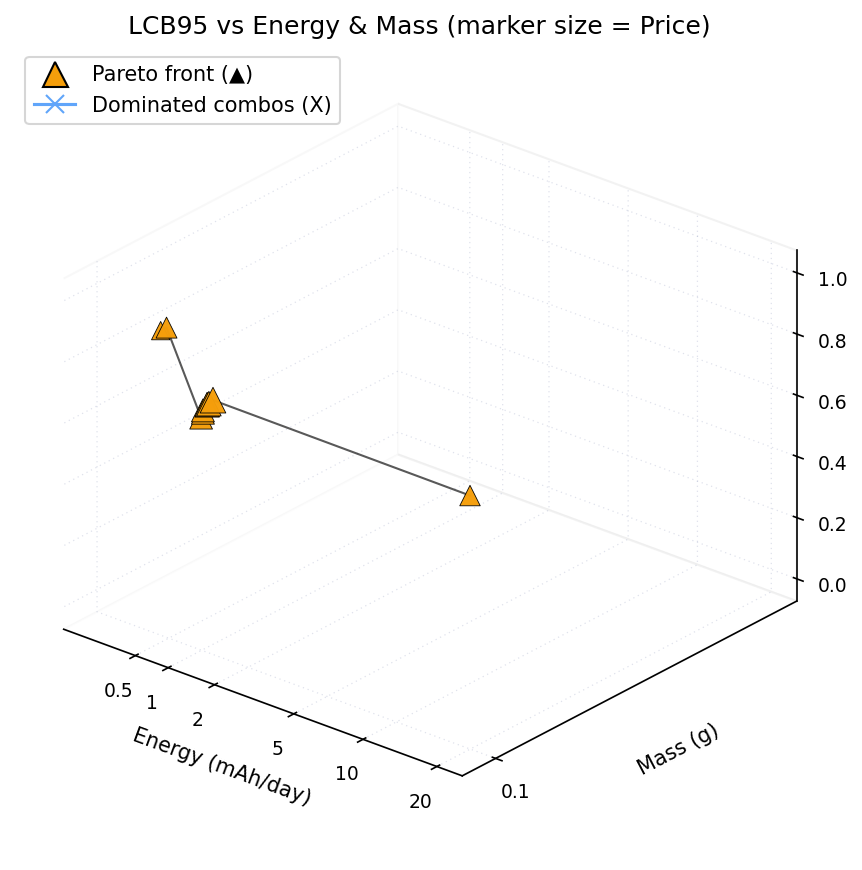

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

# -----------------------------
# 工具：非支配前沿（若 df 无 ParetoFront 列则计算）
# -----------------------------
def compute_pareto_front(df, cost_cols=("Energy_mAh_per_day", "Mass_g"), perf_col="LCB95"):
    """
    前沿定义：没有其它点在所有成本不大于、且性能不低于本点，并至少一项严格更好。
    成本是要“越小越好”，性能“越大越好”。
    """
    E = df[cost_cols[0]].to_numpy()
    M = df[cost_cols[1]].to_numpy()
    F = df[perf_col].to_numpy()
    n = len(df)
    is_front = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_front[i]:
            continue
        # 存在 j 使得 E_j<=E_i, M_j<=M_i, F_j>=F_i，且至少一项严格
        dominated = ( (E <= E[i]) & (M <= M[i]) & (F >= F[i]) )
        strictly = ( (E <  E[i]) | (M <  M[i]) | (F >  F[i]) )
        dom_by_any = dominated & strictly
        if np.any(dom_by_any):
            is_front[i] = False
    return is_front

# -----------------------------
# 工具：坐标压缩与“好看”刻度
# -----------------------------
def tf_log1p10(x):
    x = np.asarray(x, dtype=float)
    return np.log10(1.0 + np.clip(x, 0, None))

def nice_log1p_ticks(data_raw, base_candidates=None, k=6, min_gap=0.10):
    """
    从原始单位中挑最多 k 个刻度（1-2-5 序列），在 log1p10 空间中保证最小间距 min_gap。
    返回原始刻度值数组（未变换）。
    """
    dmin, dmax = float(np.min(data_raw)), float(np.max(data_raw))
    if base_candidates is None:
        mags = np.arange(-4, 5)  # 10^-4 .. 10^4
        base = np.concatenate([1*np.power(10.0, mags),
                               2*np.power(10.0, mags),
                               5*np.power(10.0, mags)])
        base = np.unique(np.r_[0.0, base])
    else:
        base = np.asarray(base_candidates, dtype=float)
    cand = base[(base >= dmin) & (base <= dmax)]
    tvals = tf_log1p10(cand)
    keep, last = [], -1e9
    for v, tv in zip(cand, tvals):
        if tv - last >= min_gap:
            keep.append(v); last = tv
        if len(keep) >= k: break
    if len(keep) == 0:
        keep = [dmin, dmax]
    return np.array(keep, dtype=float)

# -----------------------------
# 工具：去重叠标注（黄金角偏移 + 白描边）
# -----------------------------
def annotate_points_3d(ax, x, y, z, labels, indices, color="#222", fs=8, spread=0.018):
    if len(indices) == 0: return
    xr = ax.get_xlim3d(); yr = ax.get_ylim3d(); zr = ax.get_zlim3d()
    sx = (xr[1]-xr[0]) * spread
    sy = (yr[1]-yr[0]) * spread
    phi = (np.sqrt(5)-1)/2.0
    for k, i in enumerate(indices):
        dx = sx*np.cos(2*np.pi*k*phi)
        dy = sy*np.sin(2*np.pi*k*phi)
        ax.text(x[i]+dx, y[i]+dy, z[i],
                str(labels[i]),
                fontsize=fs, color=color, ha="left", va="bottom",
                path_effects=[pe.withStroke(linewidth=2.0, foreground="white")])

# -----------------------------
# 主函数：漂亮的 3D 帕累托图
# -----------------------------
def plot_pareto_3d_pretty(
    res_df: pd.DataFrame,
    log_mass=True,
    top_front_k=10,
    top_dom_k=None,   # None=标全部被支配点；否则只标前 k 个（按能耗降序）
    view_elev=26, view_azim=-50,
    dpi=150
):
    """
    需要的列：sensors, Energy_mAh_per_day, Mass_g, Price_usd, LCB95
    可选：ParetoFront（若缺失会自动计算）
    """
    df = res_df.copy()
    # need_cols = ["sensors", "Energy_mAh_per_day", "Mass_g", "Price_usd", "LCB95"]
    need_cols = ["sensors", "Energy_mAh_per_day", "Price_usd", "LCB95"]  # extend data
    for c in need_cols:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")

    if "ParetoFront" not in df.columns:
        df["ParetoFront"] = compute_pareto_front(
            df, cost_cols=("Energy_mAh_per_day", "Mass_g"), perf_col="LCB95"
        )

    # 数据列
    E  = df["Energy_mAh_per_day"].to_numpy()
    M  = df["Mass_g"].to_numpy()
    F  = df["LCB95"].to_numpy()
    P  = df["Price_usd"].to_numpy()
    L  = df["sensors"].astype(str).to_numpy()
    is_front = df["ParetoFront"].to_numpy()

    # 坐标变换（压缩跨度）
    X = tf_log1p10(E)
    Y = tf_log1p10(M) if log_mass else M

    # 点大小：sqrt 压缩
    Pmax = P.max() if P.max() > 0 else 1.0
    size_dom = 14 + (np.sqrt(P/Pmax))*95
    size_fr  = 22 + (np.sqrt(P/Pmax))*130

    # 颜色
    C_DOM = "#60a5fa"   # 冷蓝（被支配）
    C_FR  = "#f59e0b"   # 暖橙（前沿）

    dom_mask = ~is_front
    fr_mask  =  is_front

    # 画图
    fig = plt.figure(figsize=(9,7), dpi=dpi)
    ax  = fig.add_subplot(111, projection='3d')
    ax.set_proj_type('ortho')         # 正交投影
    ax.view_init(elev=view_elev, azim=view_azim)

    # 面板与网格（淡）
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.set_facecolor((1, 1, 1, 0.95))
    ax.grid(True, linewidth=0.6, alpha=0.18)
    # 更淡的点划线网格
    for axinfo in (ax.xaxis._axinfo, ax.yaxis._axinfo, ax.zaxis._axinfo):
        axinfo["grid"]['linestyle'] = (0, (1, 3))
        axinfo["grid"]['linewidth'] = 0.6
        axinfo["grid"]['color']     = (0.5, 0.55, 0.7, 0.25)

    # 被支配点（X）
    sc_dom = ax.scatter(X[dom_mask], Y[dom_mask], F[dom_mask],
                        s=size_dom[dom_mask], c=C_DOM, marker='x',
                        linewidths=1.3, alpha=0.95, label="Dominated combos (X)")
    # 前沿点（▲）
    sc_fr  = ax.scatter(X[fr_mask], Y[fr_mask], F[fr_mask],
                        s=size_fr[fr_mask], c=C_FR, marker='^',
                        edgecolor='k', linewidths=0.4, alpha=0.98,
                        label="Pareto front (▲)")

    # 前沿连线（按能耗从小到大）
    idx_fr = np.where(fr_mask)[0]
    idx_sort = idx_fr[np.argsort(E[fr_mask])]
    ax.plot(X[idx_sort], Y[idx_sort], F[idx_sort], color='k', lw=1.0, alpha=0.65)

    # 标注：前沿 Top-K，被支配（全部或 TopK by Energy）
    top_front_idx = idx_fr[np.argsort(F[fr_mask])[::-1][:top_front_k]]
    # print(top_front_idx)
    annotate_points_3d(ax, X, Y, F, L, top_front_idx, color="#1f2937", fs=11, spread=0.018)

    if top_dom_k is None:
        idx_dom_to_annot = np.where(dom_mask)[0]
    else:
        # 只取能耗最高的前 k 个被支配点，减少遮挡
        idx_dom = np.where(dom_mask)[0]
        idx_dom_to_annot = idx_dom[np.argsort(E[dom_mask])[::-1][:top_dom_k]]
        # print('a')
        # print(idx_dom_to_annot)
    annotate_points_3d(ax, X, Y, F, L, idx_dom_to_annot, color="#2c5a7b", fs=12, spread=0.015)

    # 轴标签
    ax.set_xlabel("Energy (mAh/day)")
    ax.set_ylabel("Mass (g)")
    ax.set_zlabel("LCB95 (Macro-F1)")

    # 刻度：原始单位显示，但位置用 log1p 后的坐标
    xticks_raw = nice_log1p_ticks(E, k=6, min_gap=0.10)
    ax.set_xticks(tf_log1p10(xticks_raw))
    ax.set_xticklabels([f"{v:g}" for v in xticks_raw])

    if log_mass:
        yticks_raw = nice_log1p_ticks(M, k=5, min_gap=0.10)
        ax.set_yticks(tf_log1p10(yticks_raw))
        ax.set_yticklabels([f"{v:g}" for v in yticks_raw])

    ax.tick_params(axis='x', labelsize=9, pad=2)
    ax.tick_params(axis='y', labelsize=9, pad=2)
    ax.tick_params(axis='z', labelsize=9, pad=2)

    # 标题 & 图例
    ax.set_title("LCB95 vs Energy & Mass (marker size = Price)")
    legend_handles = [
        Line2D([0],[0], marker="^", color="w", label="Pareto front (▲)",
               markerfacecolor=C_FR, markeredgecolor="k", markersize=12, linewidth=0.0),
        Line2D([0],[0], marker="x", color=C_DOM, label="Dominated combos (X)",
               markersize=9, linewidth=1.5),
    ]
    ax.legend(handles=legend_handles, loc="upper left", frameon=True)

    # fig.tight_layout()
    plt.show()
    return fig, ax

# -----------------------------
# 使用示例：
# 假设你已有一个 res_df（如你上面打印的 DataFrame）
# 直接调用：
fig, ax = plot_pareto_3d_pretty(res_df, log_mass=True, top_front_k=0, top_dom_k=0)
# -----------------------------


[OK] 已输出条形图：D:\code\DeepView\deepview\calculate_results\data\umineko\micro_f1_bar.png


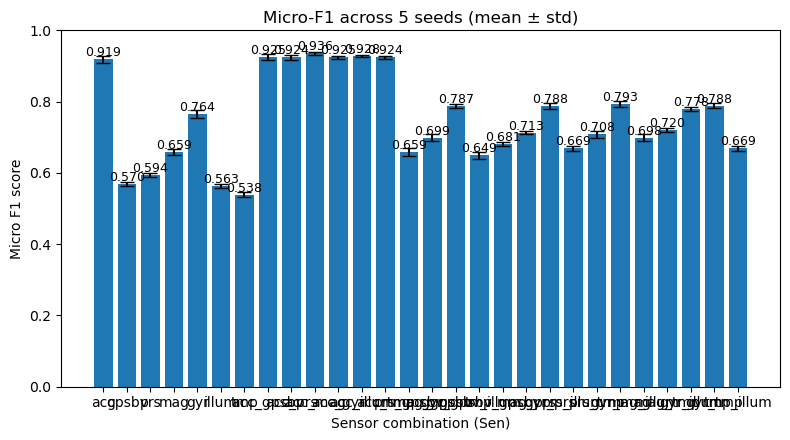

In [26]:
# 画条形图（纵轴 micro-F1，误差棒=标准差）
x = np.arange(len(all_tags))
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(x, means, yerr=stds, capsize=5)
ax.set_xticks(x)
ax.set_xticklabels(all_tags, rotation=0)
ax.set_ylabel("Micro F1 score")
ax.set_xlabel("Sensor combination (Sen)")
ax.set_ylim(0.0, 1.0)  # 微调上下界可视需要
ax.set_title(f"Micro-F1 across 5 seeds (mean ± std)")

# 在柱子顶部标数值
for rect, m in zip(bars, means):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2.0, height,
            f"{m:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
out_png = os.path.join(root_path, "micro_f1_bar.png")
plt.savefig(out_png, dpi=200)
print(f"\n[OK] 已输出条形图：{out_png}")

In [ ]:

all_combos = [['Accel','Gyro','Mag','Press','Temp','GPS','Illum'],
              ['Press', 'Temp', 'Illum'],
              ["Press", "Temp", "GPS", "Illum"],
              ['Accel'],['GPS'],['Press'],['Illum'],['Temp'],['Gyro'],['Mag'],['Accel', 'Temp'],['Press', 'Temp']] 
# ['Accel','Gyro','Mag','Press','Temp','GPS','Illum'],

raw_map = {}   # sen_tag -> list of micro-F1
summary, summary_full = [], []   # [(sen_tag, mean, var, std), ...]
all_tags = []
means, stds = [], []
for Sen in all_combos:
    vals = []
    tag = sensor_list_to_tag(Sen, compute_gps=True)  # compute_gps 来自你的管线配置
    print(tag)
    for i in range(5):
        seed_value=30+i  # i 为第几个实验
        name_label = '_supervisebase_seed%s' % str(seed_value)
        res_PKL = os.path.join(root_path, tag+'_%s_epoch%s_results.pkl'%(name_label, str(50)))  # 若用 pkl 中的权重
        macro_f1, micro_f1 = run_eval(res_PKL, Sen)
        vals.append(float(micro_f1))
    raw_map[tag] = vals

In [137]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_dot_panel(ax, tags, vals, means, stds, cis95, title=None,
                   point_alpha=0.7, seed_size=24, mean_size=90, grid=True,
                   xtick_bins=4, plot_xlabel=True):
    ax.set_axisbelow(True)
    if grid:
        ax.grid(axis='x', color='0.85', lw=0.8)
    y = np.arange(len(tags), dtype=float)

    # 5 个 seed 的小点（轻微竖向 jitter 防重叠）
    rng = np.random.default_rng(42)
    for i, v in enumerate(vals):
        jit = rng.uniform(-0.12, 0.12, size=len(v))
        ax.scatter(v, np.full_like(v, y[i]) + jit,
                   s=seed_size, alpha=point_alpha,
                   linewidths=0.5, edgecolor='white', color='#6ea8ff')

    # ±1 std 线 & 95%CI 带；均值黑点
    ax.hlines(y, means - stds,  means + stds,  lw=2.0, color='k', alpha=0.75)
    ax.hlines(y, means - cis95, means + cis95, lw=5.0, color='k', alpha=0.18)
    ax.scatter(means, y, s=mean_size, color='black', zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels(tags, fontsize=10)
    if plot_xlabel:
        ax.set_xlabel("Micro-F1 score")
    if title:
        ax.set_title(title, fontsize=14)

    # x 轴范围留白
    xmin = min(min(v) for v in vals); xmax = max(max(v) for v in vals)
    pad = max(0.01, 0.03*(xmax - xmin))
    ax.set_xlim(xmin - pad, xmax + pad)

    # —— 关键：限制刻度数量 + 固定格式，防止重叠 ——
    ax.xaxis.set_major_locator(MaxNLocator(nbins=xtick_bins, prune='both'))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.tick_params(axis='x', labelsize=10, pad=2)

    return ax

def plot_combo_with_inset(raw_map, all_combos,
                          inset_loc="lower right",
                          inset_size=("42%", "48%"),
                          figsize=(6.2, 7.4), dpi=180,
                          xtick_bins_main=4, xtick_bins_inset=4,
                          name_map=None):
    # 名称映射
    if name_map is None:
        name_map = {"Accel":"acc","GPS":"gpsbv","Press":"prs","Illum":"illum",
                    "Temp":"tmp","Gyro":"gyr","Mag":"mag"}
    from collections import defaultdict

    def norm_key(s: str) -> str:
        # 小写 + 组件排序，保证不同顺序视为同一组合
        return "_".join(sorted(s.lower().split("_")))
    
    def sensors_to_tag(sen_list, sep="_"):
        return sep.join([name_map[s] for s in sen_list])
    # 整理数据（按均值从低到高）
    def prepare_panel(tags):
        # 1) 预处理 raw_map，按规范化键聚合（把同组的值合并）
        norm_map = defaultdict(list)
        for k, vals in raw_map.items():
            nk = norm_key(k)
            arr = np.asarray(vals, dtype=float)
            arr = arr[~np.isnan(arr)]
            if arr.size:
                norm_map[nk].extend(arr.tolist())
            
        # 2) 遍历 tags，用规范化键查找
        items = []
        for t in tags:
            nt = norm_key(t)
            if nt in norm_map and len(norm_map[nt]) > 0:
                v = np.asarray(norm_map[nt], dtype=float)
                v = v[~np.isnan(v)]
                if v.size > 0:
                    # 保留原始 tag 文本 t，但值来自规范化匹配
                    items.append((t, v))
        if not items:
            return [], [], [], [], []
        items.sort(key=lambda kv: kv[1].mean())
        tags_sorted = [k for k,_ in items]
        vals = [v for _,v in items]
        means = np.array([v.mean() for v in vals])
        stds  = np.array([v.std(ddof=1) if len(v)>1 else 0.0 for v in vals])
        ns    = np.array([len(v) for v in vals])
        cis95 = 1.96 * stds / np.sqrt(np.maximum(ns, 1))
        return tags_sorted, vals, means, stds, cis95

    # 拆分单体/多组合
    single_tags = [sensors_to_tag(c) for c in all_combos if len(c) == 1]
    multi_tags  = [sensors_to_tag(c) for c in all_combos if len(c) > 1]



    tags_m, vals_m, means_m, stds_m, cis95_m = prepare_panel(multi_tags)
    tags_s, vals_s, means_s, stds_s, cis95_s = prepare_panel(single_tags)

    # 画布：更高更窄
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    plot_dot_panel(ax, tags_m, vals_m, means_m, stds_m, cis95_m,
                   title="Micro-F1 across 5 seeds (points) with mean ± std / 95% CI",
                   xtick_bins=xtick_bins_main)

    # 右下角 inset（只放单体）
    # ax_ins = inset_axes(ax, width=inset_size[0], height=inset_size[1],
    #                     loc=inset_loc, borderpad=1.0)
    ax_ins = inset_axes(
                        ax,
                        width="48%", height="48%",
                        loc="lower right",          # 仍然以右下角为参考
                        borderpad=0.8,              # 内缩一点点（可选）
                        bbox_to_anchor=(0, 0.05, 1, 1),  # 👈 往上挪动 0.06（axes 的 6% 高度）
                        bbox_transform=ax.transAxes
                        )
    plot_dot_panel(ax_ins, tags_s, vals_s, means_s, stds_s, cis95_s,
                   title=None, seed_size=20, mean_size=70, grid=True,
                   xtick_bins=xtick_bins_inset, plot_xlabel=False)
    ax_ins.set_ylabel("")
    for lbl in ax_ins.get_yticklabels():
        lbl.set_fontsize(9)
    for spine in ax_ins.spines.values():
        spine.set_alpha(0.4)

    # plt.tight_layout()
    return fig, ax, ax_ins


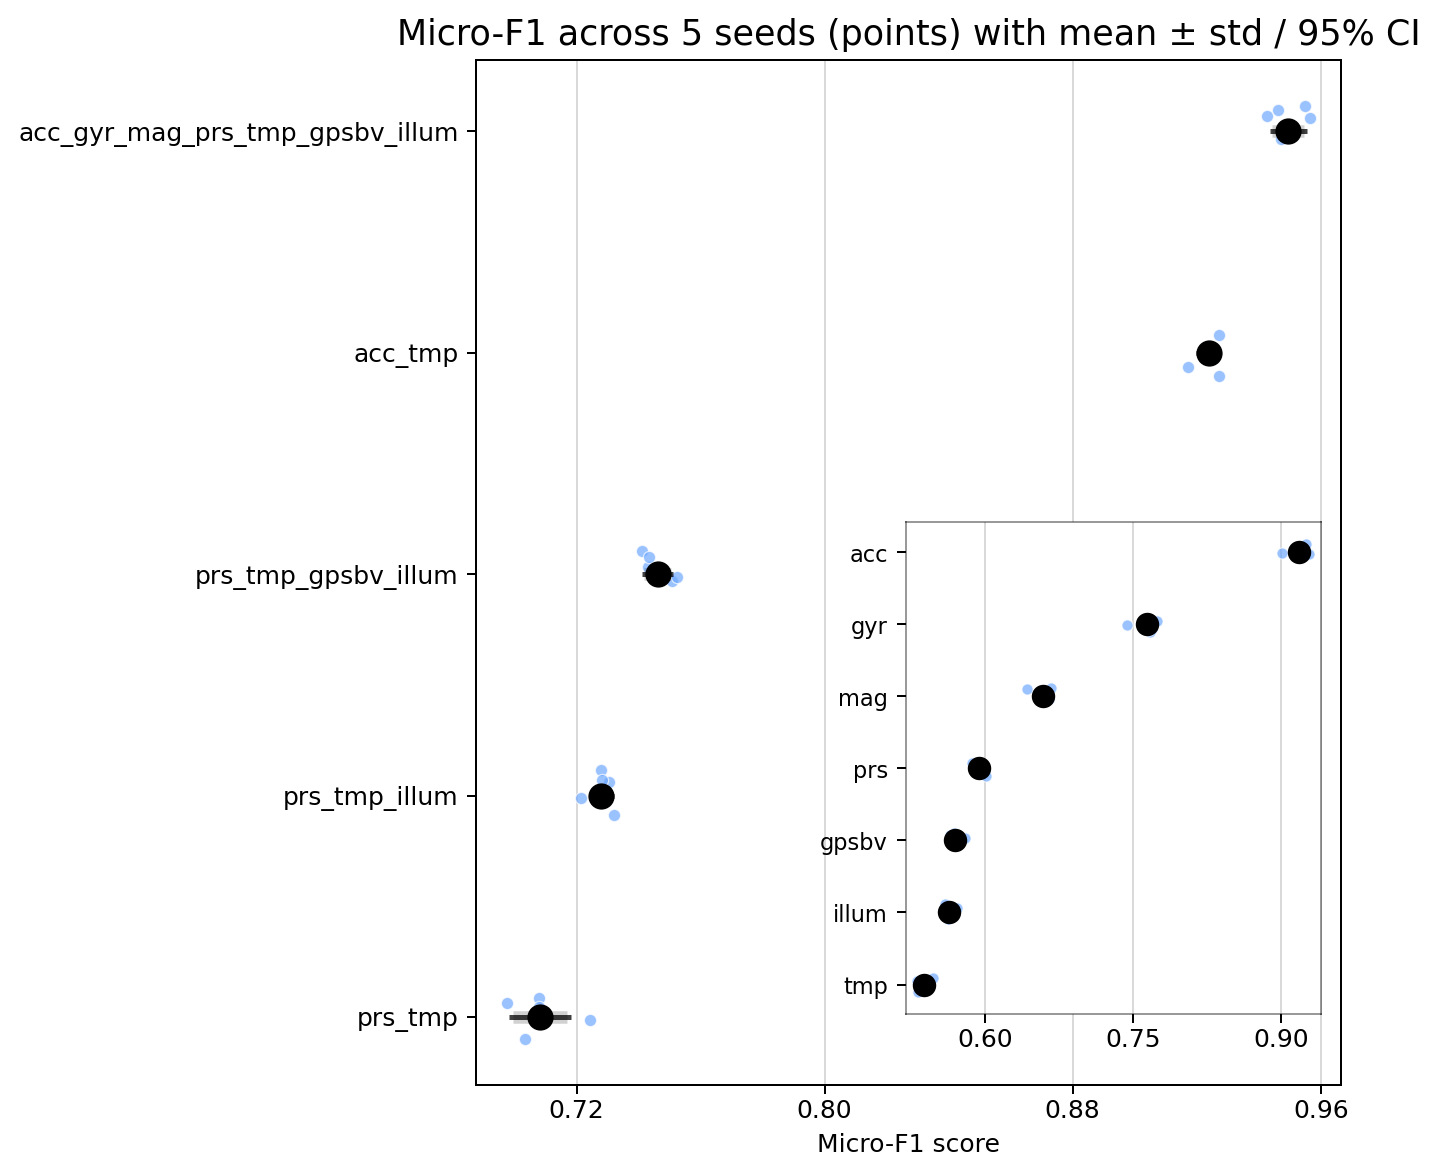

In [138]:
fig, ax, ax_ins = plot_combo_with_inset(raw_map, all_combos)

# omizunagidori 的Figure5结果(Syn_LCB)，证明和umineko差不多，可以迁移

In [ ]:
## 选择传感器类型
sensor_list=["Accel", "GPS", "Press", "Mag", "Gyro", "Illum", "Temp"]
pair_list = [list(p) for p in combinations(sensor_list, 2)]
sensor_list = [[s] for s in sensor_list]
all_sensor_list = sensor_list + pair_list
# all_sensor_list


# root_path = r'D:\code\DeepView\deepview\calculate_results\data\omizunagidori'

raw_map = {}   # sen_tag -> list of micro-F1
summary, summary_full = [], []   # [(sen_tag, mean, var, std), ...]
all_tags = []
means, stds = [], []
for Sen in all_sensor_list:
    vals = []
    tag = sensor_list_to_tag(Sen, compute_gps=True)  # compute_gps 来自你的管线配置
    print(tag)
    for i in range(5):
        seed_value=30+i  # i 为第几个实验
        name_label = '_supervisebase_seed%s' % str(seed_value)
        res_PKL = os.path.join(root_path, tag+'_%s_epoch%s_results.pkl'%(name_label, str(50)))  # 若用 pkl 中的权重
        macro_f1, micro_f1 = run_eval(res_PKL, Sen)
        vals.append(float(micro_f1))
    raw_map[tag] = vals

    m = float(np.mean(vals))
    v = float(np.var(vals, ddof=1))   # 样本方差
    s = float(np.std(vals, ddof=1))   # 样本标准差
    summary.append((tag, m, v, s))  # 作条形图
    summary_full.append((tag, vals))
    all_tags.append(tag)
    means.append(m)
    stds.append(s)


In [17]:
rows = []
count = 1
for s_info in summary_full:
    s = tag2sensor[s_info[0]]
    # print(f"{s}: {s_info[1]}")
    # print(s_info[1])
    rows.append({"combo_id": str(count), "sensors": s, "F1_run1":s_info[1][0], "F1_run2":s_info[1][1], "F1_run3":s_info[1][2], "F1_run4":s_info[1][3], "F1_run5":s_info[1][4]})
    count += 1

perf_df = pd.DataFrame(rows, columns=["combo_id","sensors","F1_run1","F1_run2","F1_run3","F1_run4","F1_run5"])


cost_map = sensor_specs.set_index("sensor")[["energy_mAh_per_day","mass_g","price_usd","volume_mm3"]].to_dict("index")


records = []
for _, r in perf_df.iterrows():
    if r["sensors"] == "ALL":
        sensor_list = ['ACC', 'GYRO', 'MAG', 'TEMP', 'ILLU', 'PRES', 'GPS']
    else:
        sensor_list = r["sensors"].split("+")
    E, M, P, V = sum_costs(sensor_list)
    runs = np.array([r[f"F1_run{i+1}"] for i in range(n_rep)], dtype=float)
    fbar = runs.mean()
    s = runs.std(ddof=1)
    lcb = float(fbar - z_095*s/np.sqrt(n_rep))
    records.append({
        "combo_id": r["combo_id"],
        "sensors": r["sensors"],
        "Energy_mAh_per_day": E,
        "Mass_g": M,
        "Price_usd": P,
        "Volume_mm3": V,
        "Fbar": fbar,
        "Std": s,
        "LCB95": lcb,
        "n_rep": n_rep
    })
res_df = pd.DataFrame(records)

In [18]:
# 含不含 '+' 的布尔掩码
has_plus = res_df["sensors"].str.contains(r"\+", na=False)

# 拆成两个 DataFrame
single_df = res_df[~has_plus].copy()  # 没有 '+' 的（单体）
pair_df   = res_df[ has_plus].copy()  # 其余（包含 '+' 的组合）

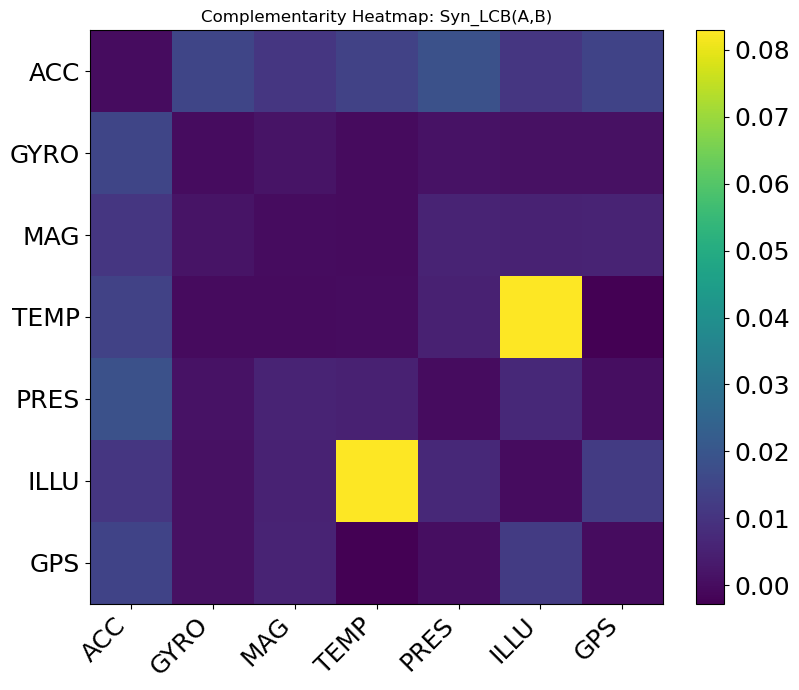

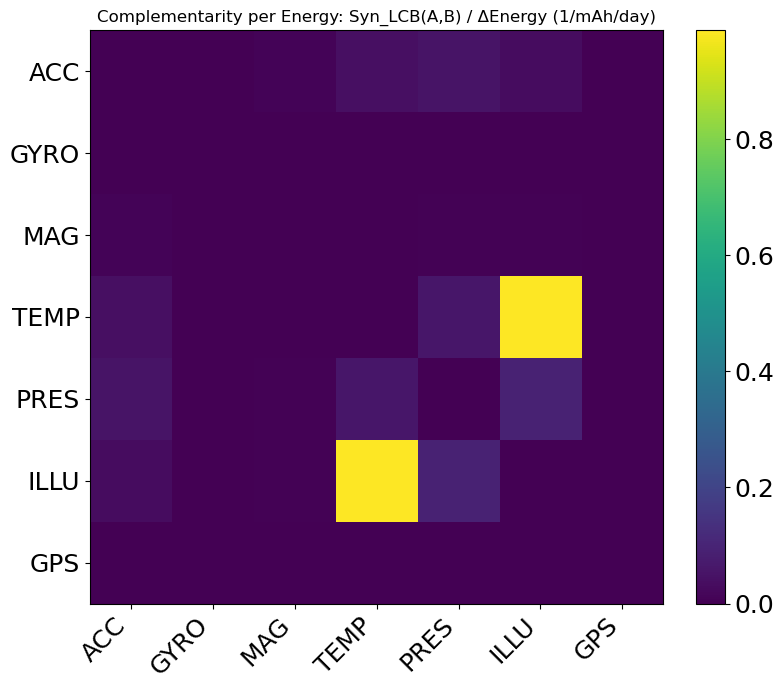

In [21]:
# ----------------------------
# 3) Compute Syn_LCB matrix
# ----------------------------
# Align lookup tables
single_lcb = dict(zip(single_df["sensors"], single_df["LCB95"]))
pair_lcb = {tuple(sorted(p["sensors"].split("+"))): p["LCB95"] for _, p in pair_df.iterrows()}

syn_mat = np.full((len(sensors), len(sensors)), np.nan, dtype=float)
for i,a in enumerate(sensors):
    for j,b in enumerate(sensors):
        if i == j:
            syn_mat[i,j] = 0.0
        else:
            key = tuple(sorted([a,b]))
            lcb_ab = pair_lcb.get(key, np.nan)
            base_ab = max(single_lcb[a], single_lcb[b])
            syn = lcb_ab - base_ab if not np.isnan(lcb_ab) else np.nan
            syn_mat[i,j] = syn

syn_df = pd.DataFrame(syn_mat, index=sensors, columns=sensors)

# (Optional) Syn per added energy (cost-normalized)
cost_map = sensor_specs.set_index("sensor")[["energy_mAh_per_day","mass_g","price_usd","volume_mm3"]].to_dict("index")
def added_energy(a,b):
    return cost_map[a]["energy_mAh_per_day"] + cost_map[b]["energy_mAh_per_day"] - min(cost_map[a]["energy_mAh_per_day"], cost_map[b]["energy_mAh_per_day"])
# simpler: just sum(a)+sum(b) - max(single) doesn't make sense; we want incremental over best single for fair "add one" scenario
# We'll compute ΔE relative to the better (lower energy) single by default:
def delta_energy_over_best_single(a,b):
    Ea, Eb = cost_map[a]["energy_mAh_per_day"], cost_map[b]["energy_mAh_per_day"]
    # when you "upgrade" from the cheaper-energy single to pair(a,b), ΔE is the energy of the other one
    return max(Ea, Eb)

syn_per_mAh = np.zeros_like(syn_mat, dtype=float)
for i,a in enumerate(sensors):
    for j,b in enumerate(sensors):
        if i == j:
            syn_per_mAh[i,j] = 0.0
        else:
            dE = delta_energy_over_best_single(a,b)
            syn_per_mAh[i,j] = syn_mat[i,j]/dE if dE>0 else np.nan
syn_per_mAh_df = pd.DataFrame(syn_per_mAh, index=sensors, columns=sensors)

# ----------------------------
# 4) Heatmap (matplotlib; no seaborn; one chart per figure)
# ----------------------------
fig1 = plt.figure(figsize=(9,7))
ax1 = fig1.add_subplot(111)
im1 = ax1.imshow(syn_mat, interpolation='nearest')
ax1.set_xticks(range(len(sensors)))
ax1.set_yticks(range(len(sensors)))
ax1.set_xticklabels(sensors, rotation=45, ha="right")
ax1.set_yticklabels(sensors)
ax1.set_title("Complementarity Heatmap: Syn_LCB(A,B)")
# fig1.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
# 放大坐标轴刻度整体字号
ax1.tick_params(axis='both', labelsize=18)
# 放大colorbar刻度
cbar = fig1.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=18)
fig1.tight_layout()


# fig_path1 = "/mnt/data/syn_heatmap.png"
# plt.savefig(fig_path1, dpi=180, bbox_inches="tight")
# plt.show()

fig2 = plt.figure(figsize=(9,7))
ax2 = fig2.add_subplot(111)
im2 = ax2.imshow(syn_per_mAh, interpolation='nearest')
ax2.set_xticks(range(len(sensors)))
ax2.set_yticks(range(len(sensors)))
ax2.set_xticklabels(sensors, rotation=45, ha="right")
ax2.set_yticklabels(sensors)
ax2.set_title("Complementarity per Energy: Syn_LCB(A,B) / ΔEnergy (1/mAh/day)")

# 放大坐标轴刻度整体字号
ax2.tick_params(axis='both', labelsize=18)
# 放大colorbar刻度
cbar = fig2.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=18)
fig2.tight_layout()
# fig_path2 = "/mnt/data/syn_per_energy_heatmap.png"
# plt.savefig(fig_path2, dpi=180, bbox_inches="tight")
plt.show()


In [23]:
syn_per_mAh

array([[ 0.00000000e+00,  7.65367896e-04,  1.12913192e-02,
         4.03204756e-02,  5.29610404e-02,  3.06941087e-02,
         8.53229053e-05],
       [ 7.65367896e-04,  0.00000000e+00,  7.96319647e-05,
        -1.64546881e-05,  6.40175726e-05,  5.30537140e-05,
         5.52615339e-06],
       [ 1.12913192e-02,  7.96319647e-05,  0.00000000e+00,
        -2.05060406e-04,  5.90729041e-03,  5.58738960e-03,
         3.52434623e-05],
       [ 4.03204756e-02, -1.64546881e-05, -2.05060406e-04,
         0.00000000e+00,  6.09778979e-02,  9.87360349e-01,
        -1.64365545e-05],
       [ 5.29610404e-02,  6.40175726e-05,  5.90729041e-03,
         6.09778979e-02,  0.00000000e+00,  9.40129888e-02,
         1.66178694e-06],
       [ 3.06941087e-02,  5.30537140e-05,  5.58738960e-03,
         9.87360349e-01,  9.40129888e-02,  0.00000000e+00,
         7.28464700e-05],
       [ 8.53229053e-05,  5.52615339e-06,  3.52434623e-05,
        -1.64365545e-05,  1.66178694e-06,  7.28464700e-05,
         0.0000000

[Spearman] rho=-0.368, permutation p=0.09979 (two-sided, n_perm=10000), N=21)


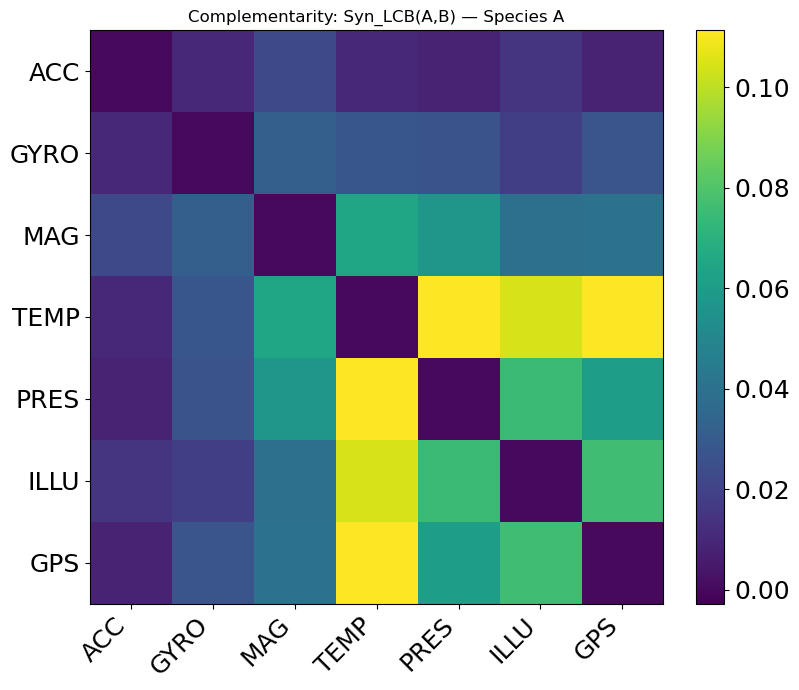

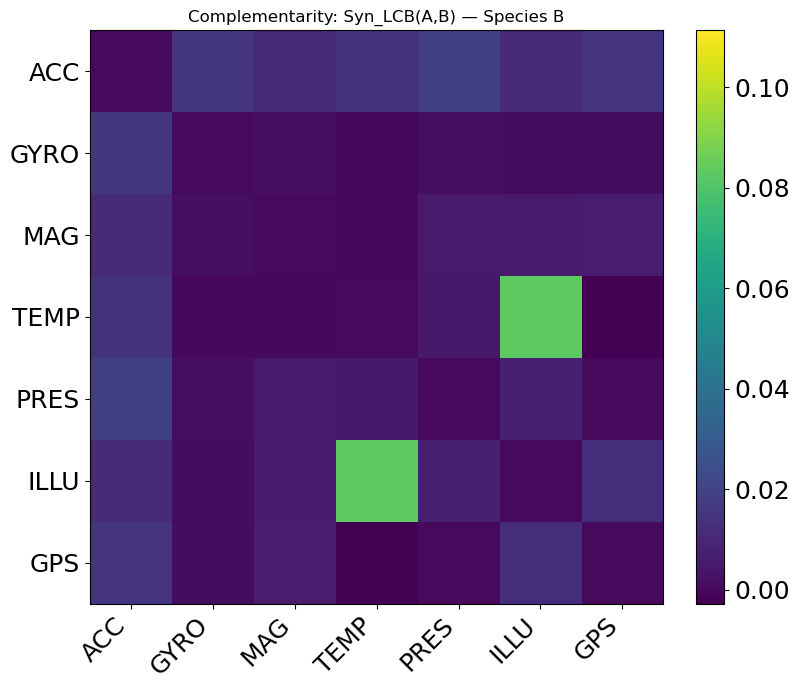

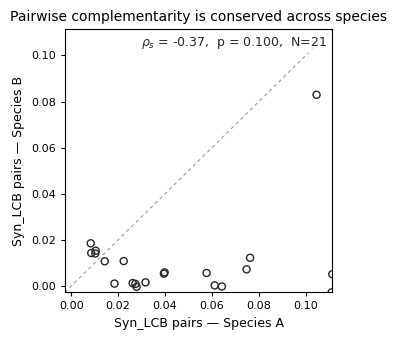

In [34]:
# ============================
# Cross-species consistency of Syn_LCB(A,B)
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Spearman实现（无scipy也能跑） ---
try:
    from scipy.stats import spearmanr, rankdata
except Exception:
    def rankdata(a):
        a = np.asarray(a)
        tmp = a.argsort()
        ranks = np.empty_like(tmp, dtype=float)
        ranks[tmp] = np.arange(len(a)) + 1
        # 简单处理ties（平均秩）
        _, inv, counts = np.unique(a, return_inverse=True, return_counts=True)
        sums = np.bincount(inv, ranks)
        avg = sums / counts
        return avg[inv]

    def spearmanr(x, y):
        rx = rankdata(x)
        ry = rankdata(y)
        r = np.corrcoef(rx, ry)[0,1]
        return r, np.nan

def spearman_perm_test(x, y, n_perm=10000, seed=0):
    """two-sided permutation p-value on Spearman rho"""
    rng = np.random.default_rng(seed)
    rho_obs, _ = spearmanr(x, y)
    cnt = 0
    for _ in range(n_perm):
        y_perm = rng.permutation(y)
        rho_perm, _ = spearmanr(x, y_perm)
        if abs(rho_perm) >= abs(rho_obs):
            cnt += 1
    p = (cnt + 1) / (n_perm + 1)
    return float(rho_obs), float(p)

def compute_syn_and_ci(single_df, pair_df, sensors):
    """
    返回：
      syn_df: Syn_LCB 矩阵（用 LCB95 计算）
      lo_df / hi_df: 若提供了 UCB95，则给出保守CI边界对应的矩阵，否则为 None
    说明：
      Syn = LCB_pair - max(LCB_single_a, LCB_single_b)
      保守下界 = LCB_pair - max(UCB_single_a, UCB_single_b)
      保守上界 = UCB_pair - max(LCB_single_a, LCB_single_b)
    """
    # 必需
    single_lcb = dict(zip(single_df["sensors"], single_df["LCB95"]))
    pair_lcb   = {tuple(sorted(r["sensors"].split("+"))): r["LCB95"] for _, r in pair_df.iterrows()}

    # 可选 UCB95
    has_ucb = "UCB95" in single_df.columns and "UCB95" in pair_df.columns
    single_ucb = dict(zip(single_df["sensors"], single_df["UCB95"])) if has_ucb else None
    pair_ucb   = ({tuple(sorted(r["sensors"].split("+"))): r["UCB95"] for _, r in pair_df.iterrows()}
                  if has_ucb else None)

    n = len(sensors)
    syn = np.full((n, n), np.nan, float)
    syn_lo = np.full((n, n), np.nan, float) if has_ucb else None
    syn_hi = np.full((n, n), np.nan, float) if has_ucb else None

    for i, a in enumerate(sensors):
        for j, b in enumerate(sensors):
            if i == j:
                syn[i, j] = 0.0
                if has_ucb:
                    syn_lo[i, j] = 0.0
                    syn_hi[i, j] = 0.0
                continue
            key = tuple(sorted([a, b]))
            lcb_ab = pair_lcb.get(key, np.nan)
            base_ab = max(single_lcb.get(a, np.nan), single_lcb.get(b, np.nan))
            syn[i, j] = lcb_ab - base_ab if (not np.isnan(lcb_ab) and not np.isnan(base_ab)) else np.nan

            if has_ucb:
                l_ab_lo = lcb_ab
                l_ab_hi = pair_ucb.get(key, np.nan)
                s_a_l, s_a_u = single_lcb.get(a, np.nan), single_ucb.get(a, np.nan)
                s_b_l, s_b_u = single_lcb.get(b, np.nan), single_ucb.get(b, np.nan)
                if np.isnan([l_ab_lo, l_ab_hi, s_a_l, s_a_u, s_b_l, s_b_u]).any():
                    syn_lo[i, j] = np.nan
                    syn_hi[i, j] = np.nan
                else:
                    # 保守传播（区间运算）
                    lo = l_ab_lo - max(s_a_u, s_b_u)
                    hi = l_ab_hi - max(s_a_l, s_b_l)
                    syn_lo[i, j] = lo
                    syn_hi[i, j] = hi

    return (pd.DataFrame(syn, index=sensors, columns=sensors),
            pd.DataFrame(syn_lo, index=sensors, columns=sensors) if has_ucb else None,
            pd.DataFrame(syn_hi, index=sensors, columns=sensors) if has_ucb else None)

def upper_tri_vector(df):
    m = df.values
    idx = np.triu_indices_from(m, k=1)
    return m[idx], list(zip(df.index.values[idx[0]], df.columns.values[idx[1]]))

def vectorize_with_ci(syn_df, lo_df=None, hi_df=None):
    x, pairs = upper_tri_vector(syn_df)
    if lo_df is None or hi_df is None:
        return x, pairs, None, None
    lo, _ = upper_tri_vector(lo_df)
    hi, _ = upper_tri_vector(hi_df)
    # 误差条：相对于点的下/上偏差（允许非对称）
    err_low  = np.maximum(0.0, x - lo)
    err_high = np.maximum(0.0, hi - x)
    return x, pairs, err_low, err_high

def plot_heatmap_common_scale(syn_A, syn_B, sensors, titleA="Species A", titleB="Species B"):
    vmin = np.nanmin([syn_A.values, syn_B.values])
    vmax = np.nanmax([syn_A.values, syn_B.values])

    # A
    figA = plt.figure(figsize=(9,7))
    axA = figA.add_subplot(111)
    imA = axA.imshow(syn_A.values, interpolation='nearest', vmin=vmin, vmax=vmax)
    axA.set_xticks(range(len(sensors))); axA.set_yticks(range(len(sensors)))
    axA.set_xticklabels(sensors, rotation=45, ha="right"); axA.set_yticklabels(sensors)
    axA.set_title(f"Complementarity: Syn_LCB(A,B) — {titleA}")
    axA.tick_params(axis='both', labelsize=18)
    cbarA = figA.colorbar(imA, ax=axA, fraction=0.046, pad=0.04); cbarA.ax.tick_params(labelsize=18)
    figA.tight_layout()

    # B
    figB = plt.figure(figsize=(9,7))
    axB = figB.add_subplot(111)
    imB = axB.imshow(syn_B.values, interpolation='nearest', vmin=vmin, vmax=vmax)
    axB.set_xticks(range(len(sensors))); axB.set_yticks(range(len(sensors)))
    axB.set_xticklabels(sensors, rotation=45, ha="right"); axB.set_yticklabels(sensors)
    axB.set_title(f"Complementarity: Syn_LCB(A,B) — {titleB}")
    axB.tick_params(axis='both', labelsize=18)
    cbarB = figB.colorbar(imB, ax=axB, fraction=0.046, pad=0.04); cbarB.ax.tick_params(labelsize=18)
    figB.tight_layout()


def scatter_with_ci(x, y, ex_low=None, ex_high=None, ey_low=None, ey_high=None,
                    title="Cross-species pairwise consistency"):
    import numpy as np
    import matplotlib.pyplot as plt

    # 过滤 NaN
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x, y = x[mask], y[mask]
    if ex_low is not None:
        ex_low, ex_high = ex_low[mask], ex_high[mask]
    if ey_low is not None:
        ey_low, ey_high = ey_low[mask], ey_high[mask]

    rho, p = spearman_perm_test(x, y, n_perm=10000, seed=0)
    print(f"[Spearman] rho={rho:.3f}, permutation p={p:.4g} (two-sided, n_perm=10000), N={len(x)})")

    fig = plt.figure(figsize=(3.5, 3.5))
    ax = fig.add_subplot(111)

    if ex_low is not None and ey_low is not None:
        ax.errorbar(x, y,
                    xerr=[ex_low, ex_high],
                    yerr=[ey_low, ey_high],
                    fmt='none', ecolor='0.6', elinewidth=0.8, capsize=2, alpha=0.9, zorder=1)
    else:
        pass

    ax.scatter(x, y, s=26, facecolors='none', edgecolors='0.15', linewidths=1.0, zorder=3)

    # y=x参考线
    xymin = min(np.nanmin(x), np.nanmin(y))
    xymax = max(np.nanmax(x), np.nanmax(y))
    lo, hi = xymin, xymax
    ax.plot([lo, hi], [lo, hi], linestyle=(0, (3, 3)), linewidth=0.8, color='0.6', zorder=2)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("Syn_LCB pairs — Species A", fontsize=9)
    ax.set_ylabel("Syn_LCB pairs — Species B", fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.tick_params(direction='out', length=3, width=0.8, labelsize=8)
    for s in ax.spines.values():
        s.set_linewidth(0.8)

    # —— 把统计标注放到“图内右上角”，避免与坐标轴重合 ——
    txt = r"$\rho_s$ = {:.2f},  p = {:.3f},  N={}".format(rho, p, len(x))
    ax.text(0.98, 0.98, txt, transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='0.15',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

    fig.tight_layout()




# ============================
# 使用示例（请替换 *_A / *_B 为你的两种鸟的DF）
# ============================
# sensors = [...]  # 你的传感器列表
# single_df_A, pair_df_A = ..., ...
# single_df_B, pair_df_B = ..., ...

syn_A, lo_A, hi_A = compute_syn_and_ci(single_dfu, pair_dfu, sensors)
syn_B, lo_B, hi_B = compute_syn_and_ci(single_df, pair_df, sensors)

# 1) 统一色标的两张热图
plot_heatmap_common_scale(syn_A, syn_B, sensors, titleA="Species A", titleB="Species B")

# 2) 上三角展开 + Spearman + 置换检验 + 误差条散点
x, pairsA, ex_lo, ex_hi = vectorize_with_ci(syn_A, lo_A, hi_A)
y, pairsB, ey_lo, ey_hi = vectorize_with_ci(syn_B, lo_B, hi_B)
scatter_with_ci(x, y, ex_lo, ex_hi, ey_lo, ey_hi,
                title="Pairwise complementarity is conserved across species")


# new 

In [76]:
import pickle
import random
import torch.nn as nn
from torch import optim

from deepview.calculate_results.data.umineko.train_func import (
    train_model,
    # evaluate_model,
)

import numpy as np
import pandas as pd

# —— 复用你项目中的数据/模型工具（保持接口一致） ——
from deepview.calculate_results.models.utils import (
    sensor_list_to_tag,
    read_sensor_data,
)

import os
import copy
import torch
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support

# —— 复用你项目中的数据/模型工具（保持接口一致） ——
from deepview.calculate_results.models.utils import (
    data_loader_umineko,
    majority_value,
    sliding_window,
    process_sensors,
    sensor_list_to_tag,
    # read_sensor_data,
)


# from deepview.calculate_results.data.omizunagidori.active_supContrast import read_sensor_data
from deepview.calculate_results.data.umineko.model_func import get_model_for_sensors
from deepview.calculate_results.data.umineko.train_func import evaluate_model
from itertools import combinations
# import numpy as np
# import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def set_random_seed(seed):
    # Set seed for Python's random module
    random.seed(seed)
    # Set seed for NumPy
    np.random.seed(seed)
    # Set seed for PyTorch
    torch.manual_seed(seed)
    # If using CUDA, set seed for GPU as well
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups


def accuracy_class(predict_labels, true_labels):
    # 1. 获取唯一类别
    unique_classes = np.unique(true_labels)

    # 2. 计算每个类别的准确率
    class_accuracies = {}
    for cls in unique_classes:
        # 筛选出属于当前类别的样本
        class_indices = true_labels == cls
        # 计算预测正确的数量和总数量
        correct_predictions = np.sum(predict_labels[class_indices] == true_labels[class_indices])
        total_samples = np.sum(class_indices)
        # 计算准确率
        accuracy = correct_predictions / total_samples if total_samples > 0 else 0
        class_accuracies[cls] = accuracy

    # 输出每个类别的准确率
    for cls, acc in class_accuracies.items():
        print(f"Class {cls}: Accuracy = {acc:.2f}")


#-------------------------parameters---------------------------

device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
len_sw = 50
batch_size = 2000
num_epochs = 50
# all_sensor_list = [["Gyro"], ["Mag", "Illum", "Temp", "Press"], ["Mag", "Illum", "Temp"],
#               ["Mag", "Illum", "Press"], ["Mag", "Temp", "Press"],
#               ["Mag", "Illum"], ["Mag", "Temp"], ["Mag", "Press"],
#               ["Accel", "Illum"], ["Accel"]]  # 需要在完成syn lcb后确认
# all_sensor_list = [ ["Mag", "Illum", "Temp"], ["Gyro"]]

bird = 'umineko'  # 'umineko' or 'omizunagidori'
if bird=='umineko':
    from deepview.calculate_results.models.utils import read_sensor_data
    root_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko'
elif bird=='omizunagidori':
    from deepview.calculate_results.data.omizunagidori.active_supContrast import read_sensor_data
    root_path = r'D:\code\DeepView\deepview\calculate_results\data\omizunagidori'
else:
    print('error, other animals')

sensor_specs = pd.DataFrame([
    {"sensor":"ACC",   "energy_mAh_per_day":0.35, "mass_g":0.135, "price_usd":2.5,  "volume_mm3":4.0},
    {"sensor":"GYRO",  "energy_mAh_per_day":20.0, "mass_g":0.098, "price_usd":4.5,  "volume_mm3":6.0},
    {"sensor":"MAG",   "energy_mAh_per_day":0.96, "mass_g":0.078, "price_usd":5.0,  "volume_mm3":4.0},
    {"sensor":"TEMP",  "energy_mAh_per_day":0.084,"mass_g":0.012, "price_usd":3.0,  "volume_mm3":3.0},
    {"sensor":"PRES",  "energy_mAh_per_day":0.077,"mass_g":0.015, "price_usd":3.1,  "volume_mm3":3.0},
    {"sensor":"ILLU", "energy_mAh_per_day":0.060,"mass_g":0.008, "price_usd":2.6,  "volume_mm3":2.6},
    {"sensor":"GPS",   "energy_mAh_per_day":168.0,"mass_g":0.500, "price_usd":22.0, "volume_mm3":245.0},
])

# n_rep = 5  # repeat 5 times
z_095 = 1.645  # 95% confidence interval z value

WEIGHTS_PATH = None                 # 或者指定模型权重文件 .pt/.pth；若设置了此项，将忽略 RESULTS_PKL
WEIGHT_IDX = -1                     # 从 results.pkl 的 weight_list 里取第几个（-1 表示最后一个）
# LEN_SW = 50                         # 滑窗长度，需与训练一致
TEST_SIZE = 0.2                     # 测试集比例
SEED = 42                           # train_test_split 的随机种子（与训练保持一致）
# DEVICE = "cuda:0"                   # 自动：'cuda:0' if torch.cuda.is_available() else 'cpu'


sensors = ["ACC","GYRO","MAG","TEMP","PRES","ILLU","GPS"]

tag2sensor = {
    'acc': 'ACC',
    'tmp': 'TEMP',
    'gpsbv': 'GPS',
    'prs': 'PRES',
    'gyr': 'GYRO',
    'mag': 'MAG',
    'illum': 'ILLU',

    'acc_tmp': 'ACC+TEMP',
    'acc_gpsbv': 'ACC+GPS',
    'acc_gyr': 'ACC+GYRO',
    'acc_prs': 'ACC+PRES',
    'acc_mag': 'ACC+MAG',
    'acc_illum': 'ACC+ILLU',

    'prs_tmp': 'PRES+TEMP',
    'prs_gpsbv': 'PRES+GPS',
    'prs_illum': 'PRES+ILLU',

    'gyr_gpsbv': 'GYRO+GPS',
    'gyr_mag': 'GYRO+MAG',
    'gyr_illum': 'GYRO+ILLU',
    'gyr_tmp': 'GYRO+TEMP',
    'gyr_prs': 'GYRO+PRES',

    'mag_illum': 'MAG+ILLU',
    'mag_prs': 'MAG+PRES',
    'mag_tmp': 'MAG+TEMP',
    'mag_gpsbv': 'MAG+GPS',

    'tmp_gpsbv': 'TEMP+GPS',
    'tmp_illum': 'TEMP+ILLU',

    'gpsbv_illum': 'GPS+ILLU',

    'prs_tmp_illum': 'PRES+TEMP+ILLU',
    'prs_tmp_gpsbv_illum': 'PRES+TEMP+GPS+ILLU',
    'prs_tmp_illum_gpsbv': 'PRES+TEMP+ILLU+GPS',

    'mag_prs_tmp_illum': 'MAG+PRES+TEMP+ILLU',
    'mag_prs_illum': 'MAG+PRES+ILLU',
    'mag_prs_tmp': 'MAG+PRES+TEMP',
    'mag_illum_tmp': 'MAG+ILLU+TEMP',
    'mag_illum_prs': 'MAG+ILLU+PRES',
    'mag_tmp_illum': 'MAG+TEMP+ILLU',
}
#-------------------------parameters---------------------------

def sum_costs(senl):
    E = M = P = V = 0.0
    for s in senl:
        E += cost_map[s]["energy_mAh_per_day"]
        M += cost_map[s]["mass_g"]
        P += cost_map[s]["price_usd"]
        V += cost_map[s]["volume_mm3"]
    return E, M, P, V

def build_dataset_for_sensors(sensor_type, len_sw=50, compute_gps=True):
    """
    与训练一致的数据构造：
    - 若缓存 {tag}_data.npz 存在则直接读；
    - 否则 read_sensor_data -> process_sensors -> sliding_window，并缓存。
    输出形状 [B, C, T]，label_b 为 [B, T]（与你训练脚本一致的转置约定）。
    """
    tag = sensor_list_to_tag(sensor_type, compute_gps=compute_gps)
    # cache_path = f"{tag}_data.npz"
    cache_path = os.path.join(root_path, f"{tag}_data.npz")

    # if os.path.exists(cache_path):
    if 0:  # todo, 因为read sensor data函数错误，重新计算
        with np.load(cache_path, allow_pickle=False) as f:
            data_b = f["data"]
            label_b = f["label"]
    else:
        all_df = read_sensor_data()
        selected_df = all_df[all_df.label_id != -2]
        selected_np, _ = process_sensors(selected_df, sensor_type)

        tmp_b = sliding_window(selected_np, len_sw, len_sw)
        data_b = np.transpose(tmp_b[:, :, :-1], (0, 2, 1))  # [B, Len, dim-1] -> [B, dim-1, Len]
        label_b = tmp_b[:, :, -1]
        np.savez_compressed(cache_path, data=data_b.astype(np.float32), label=label_b)

    return data_b, label_b, tag


def stratified_train_test_split(data_b, label_b, test_size=TEST_SIZE, seed=SEED):
    """
    用多数投票标签 vote_label 做分层切分（与训练保持一致）。
    """
    vote_label = majority_value(label_b)
    X_train, X_test, y_train, y_test = train_test_split(
        data_b,
        label_b,
        test_size=test_size,
        stratify=vote_label,
        random_state=seed,
    )
    return X_train, X_test, y_train, y_test


def build_model(sensor_type, num_classes, state_dict=None, weights_path=None, device=device):
    """
    构建并加载权重：
    - 优先 weights_path 的 .pt/.pth
    - 否则使用传入的 state_dict
    """
    model = get_model_for_sensors(sensor_type, number_classes=num_classes)
    model = model.to(device)

    if weights_path is not None:
        ckpt = torch.load(weights_path, map_location=device)
        if isinstance(ckpt, dict) and "state_dict" in ckpt:
            model.load_state_dict(ckpt["state_dict"])
        elif isinstance(ckpt, dict):
            model.load_state_dict(ckpt)
        else:
            raise ValueError("Unrecognized checkpoint format for weights_path.")
    elif state_dict is not None:
        model.load_state_dict(state_dict)
    else:
        raise ValueError("Either 'state_dict' or 'weights_path' must be provided.")

    model.eval()
    return model


def build_loader(X, y, device=device, batch_size=4000):
    """
    与训练一致的数据封装到 data_loader_umineko，再用 DataLoader 包装。
    """
    major_y = majority_value(y)
    ds = data_loader_umineko(X.astype(float), major_y.astype(int), y.astype(int), device=device)
    return DataLoader(ds, batch_size=batch_size, shuffle=False, drop_last=False)



def get_supervised_results(len_sw, batch_size, num_epochs, all_sensor_list, device):

    sensor_result_dict = {}

    for sensor_type in all_sensor_list:
        if type(sensor_type) == str:
            sensor_type = [sensor_type]

        data_b, label_b, tag = build_dataset_for_sensors(sensor_type, len_sw, compute_gps=True)

        # ======= 5. 多次实验 ======= #
        test_accuracy_list, test_macro_f1_list, test_micro_f1_list = [], [], []
        test_pred_label_lists, test_truth_label_lists = [], []
        weight_list = []
        loss_list = []
        selected_labels_list = []

        # for i in range(2):
        for i in range(5):
            seed_value=30+i
            set_random_seed(seed_value)
            # name_label = '_supervisebase_seed%s' % str(seed_value)


            # 将数据分为8:2，其中2为测试集
            # todo，未来需要根据已有标签进行数据集切分
            vote_label = majority_value(label_b)
            X_train_full, X_test, y_train_full, y_test = train_test_split(data_b, label_b,
                                                                              test_size=0.2, stratify=vote_label,
                                                                              random_state=42)


            # 初始化模型和优化器
            model = get_model_for_sensors(sensor_type, number_classes=int(np.max(label_b)+1))

            model = model.to(device)  # 不需要读模型权重，模型encoder排序根据 all_sensor_list 来
            classify_criterion = nn.CrossEntropyLoss()
            optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)


            # 创建数据加载器
            major_label_b = majority_value(y_train_full)
            train_dataset = data_loader_umineko(X_train_full.astype(float),
                                                major_label_b.astype(int),
                                                y_train_full.astype(int))
            train_loader = DataLoader(train_dataset, batch_size=batch_size,
                                      shuffle=False, drop_last=False)


            ## stage 1: train supervised model, 获得分类器新参数
            model.train()
            model, avg_loss = train_model(model, train_loader, classify_criterion, optimizer,
                                          epochs=num_epochs, device=device, if_contrast=False)
            loss_list.append(avg_loss)  # 记录50次epoch的平均loss

            # ======= 6. 模型测试 ======= #

            major_label_b = majority_value(y_test)
            test_dataset = data_loader_umineko(X_test.astype(float),
                                               major_label_b.astype(int),
                                               y_test.astype(int))
            test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
            print('-------Test----------')
            print(sensor_type)
            (accuracy, macro_f1, micro_f1,
             pred_label_list, truth_label_list) = evaluate_model(model,
                                                                 test_loader,
                                                                 device)

            test_accuracy_list.append(accuracy)
            test_micro_f1_list.append(micro_f1)
            test_macro_f1_list.append(macro_f1)
            test_pred_label_lists.append(np.concatenate(pred_label_list, axis=0))
            test_truth_label_lists.append(np.concatenate(truth_label_list, axis=0))
            selected_labels_list.append(y_train_full)

            # 保存当前模型权重到列表
            weight_list.append(copy.deepcopy(model.state_dict()))


        # ======= 7. 保存结果 ======= #
        result_dict = {
            'test_accuracy_list': test_accuracy_list,
            'test_macro_f1_list': test_macro_f1_list,
            'test_micro_f1_list': test_micro_f1_list,
            'test_pred_label_lists': test_pred_label_lists,
            'test_truth_label_lists': test_truth_label_lists,
            'selected_labels_list': selected_labels_list,
            'weight_list': weight_list,
        }
        tag = sensor_list_to_tag(sensor_type, compute_gps=True)
        sensor_result_dict[tag] = result_dict

    return sensor_result_dict

def run_eval(m_weight, len_sw, device, SENSORS):
    # 1) 规范化传感器列表
    sensor_type = [s.strip() for s in SENSORS] if isinstance(SENSORS, (list, tuple)) else [str(SENSORS)]

    # 2) 构造数据
    data_b, label_b, tag = build_dataset_for_sensors(sensor_type, len_sw=len_sw)

    # 3) 切分（分层、随机种子与训练保持一致）
    X_train, X_test, y_train, y_test = stratified_train_test_split(data_b, label_b,
                                                                   test_size=TEST_SIZE,
                                                                   seed=SEED)

    # 4) 准备权重
    state_dict = copy.deepcopy(m_weight)

    # 5) 构建模型并加载权重
    num_classes = int(np.max(label_b) + 1)
    model = build_model(sensor_type, num_classes, state_dict=state_dict,
                        weights_path=WEIGHTS_PATH, device=device)

    # 6) 评估（与你训练中 evaluate_model 的返回保持一致）
    test_loader = build_loader(X_test, y_test, device=device, batch_size=4000)
    accuracy, macro_f1, micro_f1, pred_list, truth_list = evaluate_model(model, test_loader, device)

    return macro_f1, micro_f1, pred_list, truth_list




print('a')



a


In [77]:
#、、、、、、、、、、、## calculate multiple sensor combos (Syn_LCB)、、、、、、、、、、、、、、、、、

sensor_list=["Accel", "GPS", "Press", "Mag", "Gyro", "Illum", "Temp"]
pair_list = [list(p) for p in combinations(sensor_list, 2)]
sensor_list = [[s] for s in sensor_list]
sensor_combo_list = sensor_list + pair_list


sensor_result_dict = get_supervised_results(len_sw, batch_size,
                                            num_epochs,
                                            sensor_combo_list,
                                            device)



-------Test----------
['Accel']
Accuracy: 0.93, Macro F1 Score: 0.87, Weighted F1 Score: 0.93
-------Test----------
['Accel']
Accuracy: 0.93, Macro F1 Score: 0.87, Weighted F1 Score: 0.93
-------Test----------
['Accel']
Accuracy: 0.93, Macro F1 Score: 0.87, Weighted F1 Score: 0.93
-------Test----------
['Accel']
Accuracy: 0.94, Macro F1 Score: 0.87, Weighted F1 Score: 0.94
-------Test----------
['Accel']
Accuracy: 0.92, Macro F1 Score: 0.84, Weighted F1 Score: 0.92
-------Test----------
['GPS']
Accuracy: 0.65, Macro F1 Score: 0.36, Weighted F1 Score: 0.58
-------Test----------
['GPS']
Accuracy: 0.65, Macro F1 Score: 0.39, Weighted F1 Score: 0.58
-------Test----------
['GPS']
Accuracy: 0.65, Macro F1 Score: 0.40, Weighted F1 Score: 0.59
-------Test----------
['GPS']
Accuracy: 0.65, Macro F1 Score: 0.36, Weighted F1 Score: 0.57
-------Test----------
['GPS']
Accuracy: 0.66, Macro F1 Score: 0.37, Weighted F1 Score: 0.59
-------Test----------
['Press']
Accuracy: 0.66, Macro F1 Score: 0.40, 

In [78]:
raw_map = {}   # sen_tag -> list of micro-F1
summary, summary_full = [], []   # [(sen_tag, mean, var, std), ...]
all_tags = []
means, stds = [], []

for Sen in sensor_combo_list:
    tag = sensor_list_to_tag(Sen, compute_gps=True)
    sen_result_dict = sensor_result_dict[tag]
    model_weight_list = sen_result_dict['weight_list']
    vals = []
    tag = sensor_list_to_tag(Sen, compute_gps=True)  # compute_gps 来自你的管线配置
    for i in range(len(model_weight_list)):
        m_weight = model_weight_list[i]
        macro_f1, micro_f1, pred, gt = run_eval(m_weight, len_sw, device, Sen)
        vals.append(float(micro_f1))
    raw_map[tag] = vals

    m = float(np.mean(vals))
    v = float(np.var(vals, ddof=1))   # 样本方差
    s = float(np.std(vals, ddof=1))   # 样本标准差
    summary.append((tag, m, v, s))  # 作条形图
    summary_full.append((tag, vals))
    all_tags.append(tag)
    means.append(m)
    stds.append(s)

Accuracy: 0.93, Macro F1 Score: 0.87, Weighted F1 Score: 0.93
Accuracy: 0.93, Macro F1 Score: 0.87, Weighted F1 Score: 0.93
Accuracy: 0.93, Macro F1 Score: 0.87, Weighted F1 Score: 0.93
Accuracy: 0.94, Macro F1 Score: 0.87, Weighted F1 Score: 0.94
Accuracy: 0.92, Macro F1 Score: 0.84, Weighted F1 Score: 0.92
Accuracy: 0.65, Macro F1 Score: 0.36, Weighted F1 Score: 0.58
Accuracy: 0.65, Macro F1 Score: 0.39, Weighted F1 Score: 0.58
Accuracy: 0.65, Macro F1 Score: 0.40, Weighted F1 Score: 0.59
Accuracy: 0.65, Macro F1 Score: 0.36, Weighted F1 Score: 0.57
Accuracy: 0.66, Macro F1 Score: 0.37, Weighted F1 Score: 0.59
Accuracy: 0.66, Macro F1 Score: 0.40, Weighted F1 Score: 0.60
Accuracy: 0.66, Macro F1 Score: 0.41, Weighted F1 Score: 0.60
Accuracy: 0.66, Macro F1 Score: 0.41, Weighted F1 Score: 0.61
Accuracy: 0.65, Macro F1 Score: 0.39, Weighted F1 Score: 0.59
Accuracy: 0.65, Macro F1 Score: 0.42, Weighted F1 Score: 0.60
Accuracy: 0.73, Macro F1 Score: 0.54, Weighted F1 Score: 0.69
Accuracy

In [104]:

rows = []
count = 1
for s_info in summary_full:
    s = tag2sensor[s_info[0]]

    rows.append({
        "combo_id": str(count),
        "sensors": s,
        **{f"F1_run{i + 1}": v for i, v in enumerate(s_info[1])}
    })
    # print(rows[-1])
    count += 1

perf_df = pd.DataFrame(rows, columns=list(rows[0].keys()))
perf_df.head(2)

,combo_id,sensors,F1_run1,F1_run2,F1_run3,F1_run4,F1_run5
0,1,ACC,0.931295,0.933370,0.934756,0.936922,0.917269
1,2,GPS,0.579109,0.583881,0.588502,0.570674,0.587641


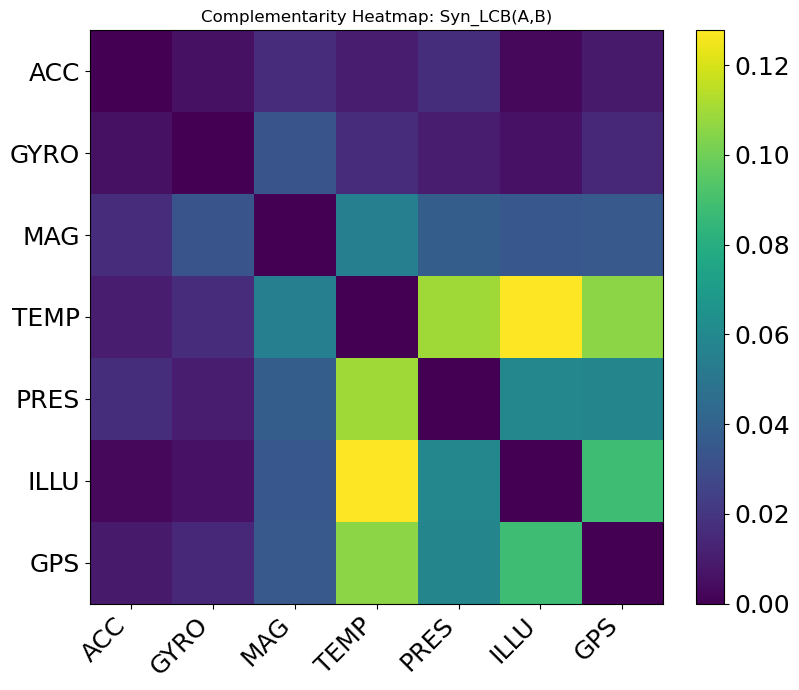

In [105]:
# -------------------------------------------------------
# 4) Compute costs by summing per-sensor specs per combo;
#    compute LCB95 from the (placeholder) 5 F1 runs.
# -------------------------------------------------------
# helper: sum costs
cost_map = sensor_specs.set_index("sensor")[["energy_mAh_per_day",
                                             "mass_g", "price_usd", "volume_mm3"]].to_dict(
    "index")

records = []
for _, r in perf_df.iterrows():
    senl = r["sensors"].split("+")
    E, M, P, V = sum_costs(senl)
    runs = np.array([value for key, value in r.items() if 'F1_run' in key], dtype=float)
    fbar = runs.mean()
    s = runs.std(ddof=1)
    lcb = float(fbar - z_095 * s / np.sqrt(len(runs)))
    records.append({
        "combo_id": r["combo_id"],
        "sensors": r["sensors"],
        "Energy_mAh_per_day": E,
        "Mass_g": M,
        "Price_usd": P,
        "Volume_mm3": V,
        "Fbar": fbar,
        "Std": s,
        "LCB95": lcb,
        # "n_rep": n_rep
    })
res_df = pd.DataFrame(records)

# ----------------------------
# 3) Compute Syn_LCB matrix
# ----------------------------
# 含不含 '+' 的布尔掩码
has_plus = res_df["sensors"].str.contains(r"\+", na=False)

# 拆成两个 DataFrame
single_dfu = res_df[~has_plus].copy()  # 没有 '+' 的（单体）
pair_dfu   = res_df[ has_plus].copy()  # 其余（包含 '+' 的组合）

# Align lookup tables
single_lcb = dict(zip(single_dfu["sensors"], single_dfu["LCB95"]))
pair_lcb = {tuple(sorted(p["sensors"].split("+"))): p["LCB95"] for _, p in pair_dfu.iterrows()}

syn_mat = np.full((len(sensors), len(sensors)), np.nan, dtype=float)
for i,a in enumerate(sensors):
    for j,b in enumerate(sensors):
        if i == j:
            syn_mat[i,j] = 0.0
        else:
            key = tuple(sorted([a,b]))
            lcb_ab = pair_lcb.get(key, np.nan)
            base_ab = max(single_lcb[a], single_lcb[b])
            syn = lcb_ab - base_ab if not np.isnan(lcb_ab) else np.nan
            syn_mat[i,j] = syn

syn_df = pd.DataFrame(syn_mat, index=sensors, columns=sensors)

# ----------------------------
# 4) Heatmap (matplotlib; no seaborn; one chart per figure)
# ----------------------------
fig1 = plt.figure(figsize=(9,7))
ax1 = fig1.add_subplot(111)
im1 = ax1.imshow(syn_mat, interpolation='nearest')
ax1.set_xticks(range(len(sensors)))
ax1.set_yticks(range(len(sensors)))
ax1.set_xticklabels(sensors, rotation=45, ha="right")
ax1.set_yticklabels(sensors)
ax1.set_title("Complementarity Heatmap: Syn_LCB(A,B)")
# fig1.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
# 放大坐标轴刻度整体字号
ax1.tick_params(axis='both', labelsize=18)
# 放大colorbar刻度
cbar = fig1.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=18)
fig1.tight_layout()
plt.show()

#### 不需要放在gui, do not run!

In [41]:
# # 根据上图确定需要绘制点图的组合
# all_sensor_list = [["Gyro"], ["Mag", "Illum", "Temp", "Press"], ["Mag", "Illum", "Temp"],
#               ["Mag", "Illum", "Press"], ["Mag", "Temp", "Press"],
#               ["Mag", "Illum"], ["Mag", "Temp"], ["Mag", "Press"],
#               ["Accel", "Illum"], ["Accel"]]  # 需要在完成syn lcb后确认

In [106]:
def plot_dot_panel(ax, tags, vals, means, stds, cis95, title=None,
                   point_alpha=0.7, seed_size=24, mean_size=90, grid=True,
                   xtick_bins=4, plot_xlabel=True):
    ax.set_axisbelow(True)
    if grid:
        ax.grid(axis='x', color='0.85', lw=0.8)
    y = np.arange(len(tags), dtype=float)

    # 5 个 seed 的小点（轻微竖向 jitter 防重叠）
    rng = np.random.default_rng(42)
    for i, v in enumerate(vals):
        jit = rng.uniform(-0.12, 0.12, size=len(v))
        ax.scatter(v, np.full_like(v, y[i]) + jit,
                   s=seed_size, alpha=point_alpha,
                   linewidths=0.5, edgecolor='white', color='#6ea8ff')

    # ±1 std 线 & 95%CI 带；均值黑点
    ax.hlines(y, means - stds,  means + stds,  lw=2.0, color='k', alpha=0.75)
    ax.hlines(y, means - cis95, means + cis95, lw=5.0, color='k', alpha=0.18)
    ax.scatter(means, y, s=mean_size, color='black', zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels(tags, fontsize=10)
    if plot_xlabel:
        ax.set_xlabel("Micro-F1 score")
    if title:
        ax.set_title(title, fontsize=14)

    # x 轴范围留白
    xmin = min(min(v) for v in vals); xmax = max(max(v) for v in vals)
    pad = max(0.01, 0.03*(xmax - xmin))
    ax.set_xlim(xmin - pad, xmax + pad)

    # —— 关键：限制刻度数量 + 固定格式，防止重叠 ——
    ax.xaxis.set_major_locator(MaxNLocator(nbins=xtick_bins, prune='both'))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.tick_params(axis='x', labelsize=10, pad=2)

    return ax

def plot_combo_with_inset(raw_map, all_combos,
                          inset_loc="lower right",
                          inset_size=("42%", "48%"),
                          figsize=(6.2, 7.4), dpi=180,
                          xtick_bins_main=4, xtick_bins_inset=4,
                          name_map=None):
    # 名称映射
    if name_map is None:
        name_map = {"Accel":"acc","GPS":"gpsbv","Press":"prs","Illum":"illum",
                    "Temp":"tmp","Gyro":"gyr","Mag":"mag"}
    from collections import defaultdict

    def norm_key(s: str) -> str:
        # 小写 + 组件排序，保证不同顺序视为同一组合
        return "_".join(sorted(s.lower().split("_")))
    
    def sensors_to_tag(sen_list, sep="_"):
        return sep.join([name_map[s] for s in sen_list])
    # 整理数据（按均值从低到高）
    def prepare_panel(tags):
        # 1) 预处理 raw_map，按规范化键聚合（把同组的值合并）
        norm_map = defaultdict(list)
        for k, vals in raw_map.items():
            nk = norm_key(k)
            arr = np.asarray(vals, dtype=float)
            arr = arr[~np.isnan(arr)]
            if arr.size:
                norm_map[nk].extend(arr.tolist())
            
        # 2) 遍历 tags，用规范化键查找
        items = []
        for t in tags:
            nt = norm_key(t)
            if nt in norm_map and len(norm_map[nt]) > 0:
                v = np.asarray(norm_map[nt], dtype=float)
                v = v[~np.isnan(v)]
                if v.size > 0:
                    # 保留原始 tag 文本 t，但值来自规范化匹配
                    items.append((t, v))
        if not items:
            return [], [], [], [], []
        items.sort(key=lambda kv: kv[1].mean())
        tags_sorted = [k for k,_ in items]
        vals = [v for _,v in items]
        means = np.array([v.mean() for v in vals])
        stds  = np.array([v.std(ddof=1) if len(v)>1 else 0.0 for v in vals])
        ns    = np.array([len(v) for v in vals])
        cis95 = 1.96 * stds / np.sqrt(np.maximum(ns, 1))
        return tags_sorted, vals, means, stds, cis95

    # 拆分单体/多组合
    single_tags = [sensors_to_tag(c) for c in all_combos if len(c) == 1]
    multi_tags  = [sensors_to_tag(c) for c in all_combos if len(c) > 1]



    tags_m, vals_m, means_m, stds_m, cis95_m = prepare_panel(multi_tags)
    tags_s, vals_s, means_s, stds_s, cis95_s = prepare_panel(single_tags)

    # 画布：更高更窄
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    plot_dot_panel(ax, tags_m, vals_m, means_m, stds_m, cis95_m,
                   title="Micro-F1 across 5 seeds (points) with mean ± std / 95% CI",
                   xtick_bins=xtick_bins_main)

    # 右下角 inset（只放单体）
    # ax_ins = inset_axes(ax, width=inset_size[0], height=inset_size[1],
    #                     loc=inset_loc, borderpad=1.0)
    ax_ins = inset_axes(
                        ax,
                        width="48%", height="48%",
                        loc="lower right",          # 仍然以右下角为参考
                        borderpad=0.8,              # 内缩一点点（可选）
                        bbox_to_anchor=(0, 0.05, 1, 1),  # 👈 往上挪动 0.06（axes 的 6% 高度）
                        bbox_transform=ax.transAxes
                        )
    plot_dot_panel(ax_ins, tags_s, vals_s, means_s, stds_s, cis95_s,
                   title=None, seed_size=20, mean_size=70, grid=True,
                   xtick_bins=xtick_bins_inset, plot_xlabel=False)
    ax_ins.set_ylabel("")
    for lbl in ax_ins.get_yticklabels():
        lbl.set_fontsize(9)
    for spine in ax_ins.spines.values():
        spine.set_alpha(0.4)

    # plt.tight_layout()
    return fig, ax, ax_ins

# 根据all_sensor_list里的组合sensor画大图，单个sensor直接用以前计算heatmap的raw_map结果
combo_list = [x for x in all_sensor_list if len(x) > 1]
combo_list += [['Accel','Gyro','Mag','Press','Temp','GPS','Illum']]

sensor_combo_dict = get_supervised_results( len_sw, batch_size,
                                            num_epochs,
                                            combo_list,
                                            device)

combo_map = {}   # sen_tag -> list of micro-F1
for Sen in combo_list:
    tag = sensor_list_to_tag(Sen, compute_gps=True)
    sen_result_dict = sensor_combo_dict[tag]
    model_weight_list = sen_result_dict['weight_list']
    vals = []
    tag = sensor_list_to_tag(Sen, compute_gps=True)  # compute_gps 来自你的管线配置
    for i in range(len(model_weight_list)):
        m_weight = model_weight_list[i]
        macro_f1, micro_f1, pred, gt = run_eval(m_weight, len_sw, device, Sen)
        vals.append(float(micro_f1))
    combo_map[tag] = vals



KeyboardInterrupt: 

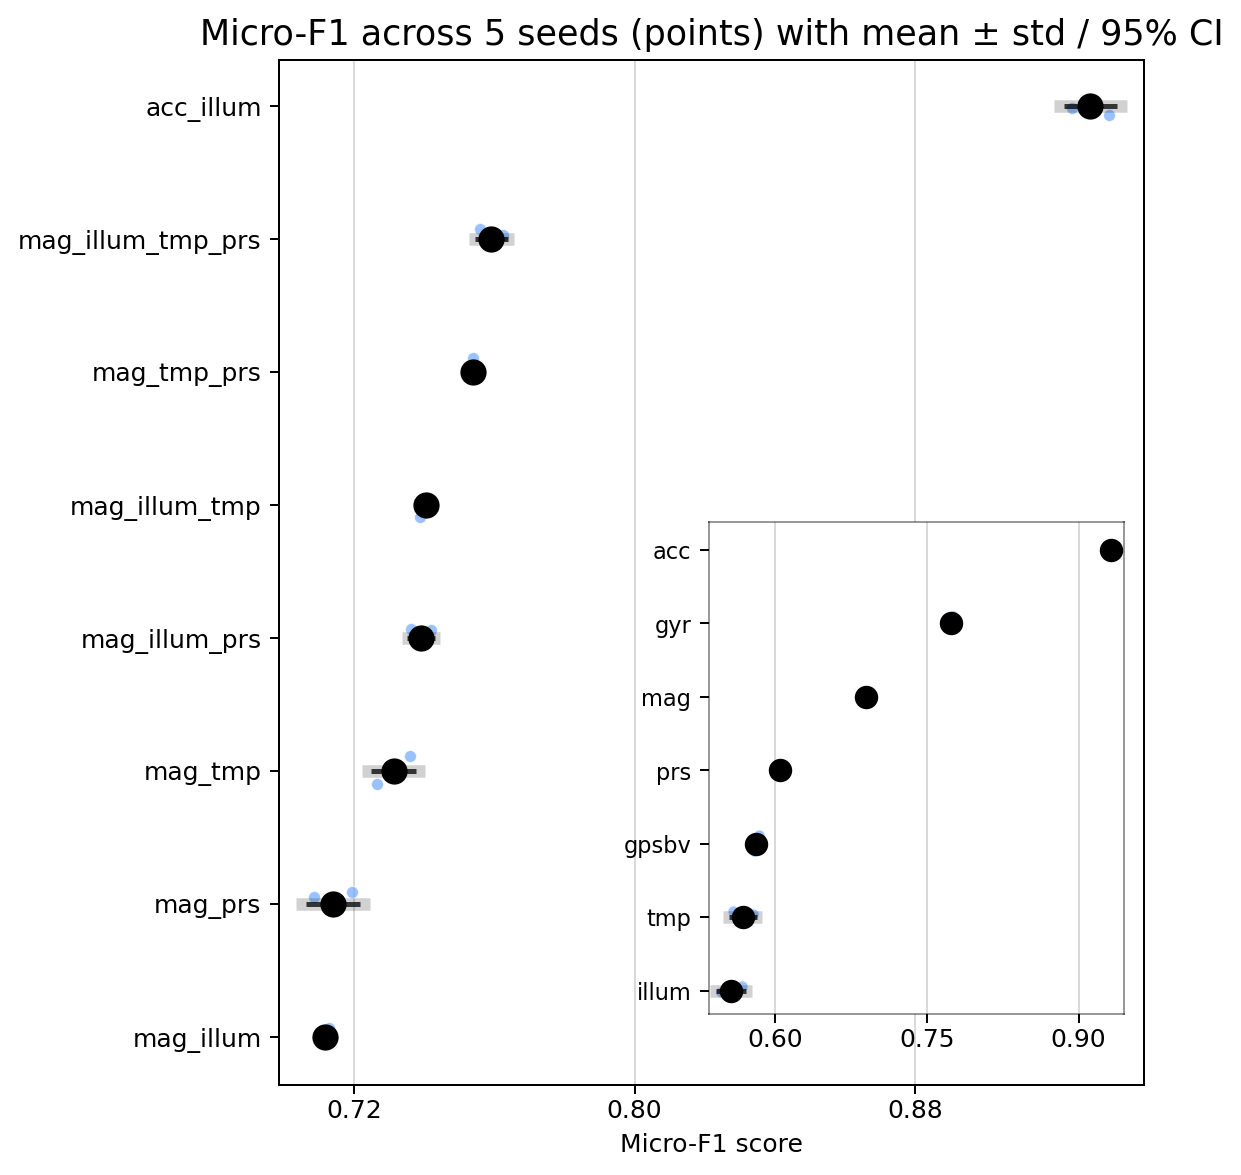

In [39]:

# all_combos = [['Accel','Gyro','Mag','Press','Temp','GPS','Illum'],
#               ['Press', 'Temp', 'Illum'],
#               ["Press", "Temp", "GPS", "Illum"],
#               ['Accel'],['GPS'],['Press'],['Illum'],['Temp'],['Gyro'],['Mag'],['Accel', 'Temp'],['Press', 'Temp']]

# all_combos = sensor_list + combo_list
# fig, ax, ax_ins = plot_combo_with_inset({**raw_map, **combo_map}, all_combos)

#### 加入gui

In [112]:
def cal_per_class(y_pred, y_true):
    
    # 用并集作为类别集合，保证“没出现的类”也能被统计到
    labels = np.unique(np.r_[y_true, y_pred])
    
    p, r, f1, s = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )
    
    per_class = pd.DataFrame(
        {"precision": p, "recall": r, "f1": f1, "support": s},
        index=labels
    )
    # print(per_class)
    return per_class

# -----------------------------
# 1) Pareto front（统一最小化）
# -----------------------------
def pareto_front(df: pd.DataFrame, minimize=(), maximize=()):
    """
    返回布尔数组 is_front，表示 df 各行是否在 Pareto 前沿上。
    - minimize: 需要“越小越好”的列名序列
    - maximize: 需要“越大越好”的列名序列

    定义：j 支配 i <=> 对所有维度 x_j <= x_i，且至少一维 x_j < x_i（严格更优）。
    对 maximize 列，先取负以统一为“越小越好”。
    """
    if not (minimize or maximize):
        raise ValueError("minimize / maximize 至少提供一个。")
    cols = list(minimize) + list(maximize)

    # 基础校验
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"缺少列: {missing}")
    if df[cols].isna().any().any():
        where = {c: df.index[df[c].isna()].tolist() for c in cols if df[c].isna().any()}
        raise ValueError(f"这些列存在 NaN: {where}")

    X = df[cols].to_numpy(dtype=float).copy()

    # 将“最大化”列取负，统一成最小化
    if maximize:
        X[:, len(minimize):] *= -1.0

    n = X.shape[0]
    is_front = np.ones(n, dtype=bool)

    # O(n^2) 非支配检测
    for i in range(n):
        if not is_front[i]:
            continue
        diff = X - X[i]               # [n, d]
        le = (diff <= 0).all(axis=1)  # 所有维度不大于
        lt = (diff <  0).any(axis=1)  # 至少一维严格小
        dominated_by_any = le & lt
        dominated_by_any[i] = False
        if dominated_by_any.any():
            is_front[i] = False
    return is_front

# -----------------------------
# 2) 坐标压缩 & “好看”刻度（可选）
# -----------------------------
def tf_log1p10(x):
    x = np.asarray(x, dtype=float)
    return np.log10(1.0 + np.clip(x, 0, None))

def nice_log1p_ticks(data_raw, k=6, min_gap=0.10):
    """
    从原始单位中挑最多 k 个刻度（1-2-5 序列），在 log1p10 空间中保证最小间距 min_gap。
    返回原始刻度值数组（未变换）。
    """
    data_raw = np.asarray(data_raw, dtype=float)
    dmin, dmax = float(np.min(data_raw)), float(np.max(data_raw))
    mags = np.arange(-4, 6)  # 10^-4 .. 10^5
    base = np.unique(np.r_[0.0,
                           1*np.power(10.0, mags),
                           2*np.power(10.0, mags),
                           5*np.power(10.0, mags)])
    cand = base[(base >= max(0.0, dmin)) & (base <= dmax)]
    tvals = tf_log1p10(cand)
    keep, last = [], -1e9
    for v, tv in zip(cand, tvals):
        if tv - last >= min_gap:
            keep.append(v); last = tv
        if len(keep) >= k:
            break
    if len(keep) == 0:
        keep = [dmin, dmax]
    return np.array(keep, dtype=float)

# -----------------------------
# 3) 去重叠文字标注（带白描边）
# -----------------------------
def _annotate_points(ax, XY_or_XYZ, labels, indices, color="#1f2937", fs=11, spread=0.015):
    # 支持 2D/3D
    is3d = (XY_or_XYZ.shape[1] == 3)
    for i in indices:
        if is3d:
            x, y, z = XY_or_XYZ[i]
            ax.text(x + spread, y + spread, z,
                    str(labels[i]), fontsize=fs, color=color,
                    ha="left", va="bottom", zorder=5,
                    path_effects=[pe.withStroke(linewidth=3, foreground="white")])
        else:
            x, y = XY_or_XYZ[i]
            ax.text(x + spread, y + spread,
                    str(labels[i]), fontsize=fs, color=color,
                    ha="left", va="bottom", zorder=5,
                    path_effects=[pe.withStroke(linewidth=3, foreground="white")])

# -----------------------------
# 4) 自适应 2D/3D Pareto 绘图
# -----------------------------
def plot_pareto_auto(
    df: pd.DataFrame,
    minimize=(),
    maximize=(),
    label_col=None,             # 标注文字来源
    marker_size_col=None,
    size_dim=None,
    log1p_cols=(),
    view_elev=26, view_azim=-50,
    dpi=150,
    annotate_front=True,        # 是否标注前沿
    front_annot_k=None,         # None=标全部前沿；int=只标前K（按第1轴排序）
    size_min=18, size_max=180,
    size_clip_quant=(0.02, 0.98),
    size_sqrt=True,
    view_mode="auto",
    # === 新增：标题与图例控制 ===
    title=None,                 # 默认无标题；给字符串则显示
    legend_loc="upper left",
    legend_bbox=(0.02, 0.98),   # 放在坐标区外侧：相对轴坐标 (x,y)
):
    # ---------- 小工具：通用标注（支持 2D/3D） ----------
    def _annotate_points(ax, X, labels, idxs, color="#1f2937", fs=10, xy_off=(4,4)):
        is3d = hasattr(ax, "zaxis")
        for i in idxs:
            if is3d:
                # 3D 直接在点位旁加一空格偏移
                ax.text(X[i,0], X[i,1], X[i,2], " " + str(labels[i]),
                        fontsize=fs, color=color, zorder=10)
            else:
                ax.annotate(str(labels[i]), (X[i,0], X[i,1]),
                            textcoords="offset points", xytext=xy_off,
                            ha="left", va="bottom", fontsize=fs, color=color)

    # ---------- 基本与校验 ----------
    dims = list(minimize) + list(maximize)
    d = len(dims)
    if d < 2 or d > 5:
        raise ValueError(f"维度需在 2~5 之间（当前 {d}）。")
    for c in dims:
        if c not in df.columns:
            raise ValueError(f"缺少列: {c}")
    df = df.copy()

    # ---------- Pareto 前沿 ----------
    if "ParetoFront" not in df.columns:
        df["ParetoFront"] = pareto_front(df, minimize=minimize, maximize=maximize)
    is_front = df["ParetoFront"].to_numpy()

    # ---------- 选择 size 源 ----------
    log1p_set = set(log1p_cols)
    size_src = None
    size_src_name = None
    if size_dim is None and d == 4:
        size_dim = dims[-1]
    if size_dim is not None:
        if size_dim not in df.columns:
            raise ValueError(f"size_dim 未找到列: {size_dim}")
        size_src_name = size_dim
        size_src = df[size_dim].to_numpy(dtype=float)
    elif marker_size_col is not None and marker_size_col in df.columns:
        size_src_name = marker_size_col
        size_src = df[marker_size_col].to_numpy(dtype=float)

    # ---------- 坐标数据 ----------
    coord_dims = [c for c in dims if c != size_dim]
    raw_cols = [df[c].to_numpy(dtype=float) for c in coord_dims]
    trans_cols = [tf_log1p10(v) if c in log1p_set else v.copy()
                  for c, v in zip(coord_dims, raw_cols)]
    X_all = np.column_stack(trans_cols)
    d_coord = X_all.shape[1]

    use_pca = (d_coord > 3)
    if not use_pca:
        X_plot = X_all[:, :min(3, d_coord)]
        axis_names = coord_dims[:min(3, d_coord)]
    else:
        Zm = X_all - X_all.mean(axis=0, keepdims=True)
        std = X_all.std(axis=0, keepdims=True); std[std==0] = 1.0
        U, S, Vt = np.linalg.svd(Zm / std, full_matrices=False)
        X_plot = U[:, :3] * S[:3]
        axis_names = ["PC1","PC2","PC3"]

    # 强制 2D/3D 视图
    if view_mode == "2d" and X_plot.shape[1] >= 2:
        X_plot = X_plot[:, :2]; axis_names = axis_names[:2]
    elif view_mode == "3d" and X_plot.shape[1] > 3:
        X_plot = X_plot[:, :3]; axis_names = axis_names[:3]

    n, k = X_plot.shape

    # ---------- 点大小 ----------
    if size_src is not None:
        v = size_src.copy()
        if size_src_name in log1p_set:
            v = tf_log1p10(np.clip(v, 0, None))
        ql, qh = np.quantile(v, size_clip_quant)
        v = np.clip(v, ql, qh)
        vmin, vmax = v.min(), v.max()
        vnorm = np.zeros_like(v) if vmax - vmin < 1e-12 else (v - vmin) / (vmax - vmin)
        if size_sqrt:
            vnorm = np.sqrt(vnorm)
        base_size = size_min + vnorm * (size_max - size_min)
        size_dom = base_size * 0.8
        size_fr  = base_size * 1.1
    else:
        size_dom = np.full(n, max(size_min, 36.0))
        size_fr  = np.full(n, max(size_min * 1.2, 64.0))

    labels = (
        df[label_col].astype(str).to_numpy()
        if (label_col and label_col in df.columns) else df.index.to_numpy()
    )

    # ---------- 颜色 ----------
    C_DOM = "#60a5fa"
    C_FR  = "#f59e0b"

    # ---------- 绘图 ----------
    fig = plt.figure(figsize=(9, 7), dpi=dpi)
    if k == 3:
        ax = fig.add_subplot(111, projection='3d')
        ax.set_proj_type('ortho')
        ax.view_init(elev=view_elev, azim=view_azim)
        for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
            pane.set_facecolor((1, 1, 1, 0.95))
        for axinfo in (ax.xaxis._axinfo, ax.yaxis._axinfo, ax.zaxis._axinfo):
            axinfo["grid"]['linestyle'] = (0, (1, 3))
            axinfo["grid"]['linewidth'] = 0.6
            axinfo["grid"]['color']     = (0.5, 0.55, 0.7, 0.25)
        ax.grid(True, linewidth=0.6, alpha=0.18)

        ax.scatter(X_plot[~is_front,0], X_plot[~is_front,1], X_plot[~is_front,2],
                   s=size_dom[~is_front], c=C_DOM, marker='x', linewidths=1.3, alpha=0.95,
                   label="Dominated combos (X)")
        ax.scatter(X_plot[ is_front,0], X_plot[ is_front,1], X_plot[ is_front,2],
                   s=size_fr[ is_front], c=C_FR, marker='^', edgecolor='k', linewidths=0.4, alpha=0.98,
                   label="Pareto front (▲)")

        idx_fr = np.where(is_front)[0]
        sorter = idx_fr[np.argsort(X_plot[idx_fr, 0])]
        if len(sorter) > 1:
            ax.plot(X_plot[sorter,0], X_plot[sorter,1], X_plot[sorter,2],
                    color='k', lw=1.0, alpha=0.65)

        # === 修复：给前沿三角点贴标签 ===
        if annotate_front and len(sorter) > 0:
            if isinstance(front_annot_k, int):
                use_idx = sorter[:front_annot_k]
            else:
                use_idx = sorter
            _annotate_points(ax, X_plot, labels, use_idx, color="#1f2937", fs=11, xy_off=(4,4))

        # 轴标签
        ax.set_xlabel(axis_names[0] + (" (log1p)" if (axis_names[0] in log1p_set and not use_pca) else ""))
        ax.set_ylabel(axis_names[1] + (" (log1p)" if (axis_names[1] in log1p_set and not use_pca) else ""))
        ax.set_zlabel(axis_names[2] + (" (log1p)" if (axis_names[2] in log1p_set and not use_pca) else ""))

        if not use_pca:
            for col_idx in (0,1,2):
                col_name = axis_names[col_idx]
                if col_name in log1p_set:
                    raw_vals = df[col_name].to_numpy(dtype=float)
                    ticks_raw = nice_log1p_ticks(raw_vals, k=6, min_gap=0.10)
                    if col_idx == 0:
                        ax.set_xticks(tf_log1p10(ticks_raw)); ax.set_xticklabels([f"{v:g}" for v in ticks_raw])
                    elif col_idx == 1:
                        ax.set_yticks(tf_log1p10(ticks_raw)); ax.set_yticklabels([f"{v:g}" for v in ticks_raw])
                    else:
                        ax.set_zticks(tf_log1p10(ticks_raw)); ax.set_zticklabels([f"{v:g}" for v in ticks_raw])

        ax.tick_params(axis='x', labelsize=9, pad=2)
        ax.tick_params(axis='y', labelsize=9, pad=2)
        ax.tick_params(axis='z', labelsize=9, pad=2)

    else:
        ax = fig.add_subplot(111)
        ax.grid(True, linewidth=0.6, alpha=0.25, linestyle=(0, (1, 3)))
        ax.scatter(X_plot[~is_front,0], X_plot[~is_front,1],
                   s=size_dom[~is_front], c=C_DOM, marker='x', linewidths=1.3, alpha=0.95,
                   label="Dominated combos (X)")
        ax.scatter(X_plot[ is_front,0], X_plot[ is_front,1],
                   s=size_fr[ is_front], c=C_FR, marker='^', edgecolor='k', linewidths=0.4, alpha=0.98,
                   label="Pareto front (▲)")

        idx_fr = np.where(is_front)[0]
        sorter = idx_fr[np.argsort(X_plot[idx_fr, 0])]
        if len(sorter) > 1:
            ax.plot(X_plot[sorter,0], X_plot[sorter,1], color='k', lw=1.0, alpha=0.65)

        if annotate_front and len(sorter) > 0:
            if isinstance(front_annot_k, int):
                use_idx = sorter[:front_annot_k]
            else:
                use_idx = sorter
            _annotate_points(ax, X_plot, labels, use_idx, color="#1f2937", fs=11, xy_off=(4,4))

        ax.set_xlabel(axis_names[0] + (" (log1p)" if (axis_names[0] in log1p_set and not use_pca) else ""))
        ax.set_ylabel(axis_names[1] + (" (log1p)" if (axis_names[1] in log1p_set and not use_pca) else ""))
        if not use_pca:
            for col_idx in (0,1):
                col_name = axis_names[col_idx]
                if col_name in log1p_set:
                    raw_vals = df[col_name].to_numpy(dtype=float)
                    ticks_raw = nice_log1p_ticks(raw_vals, k=6, min_gap=0.10)
                    if col_idx == 0:
                        ax.set_xticks(tf_log1p10(ticks_raw)); ax.set_xticklabels([f"{v:g}" for v in ticks_raw])
                    else:
                        ax.set_yticks(tf_log1p10(ticks_raw)); ax.set_yticklabels([f"{v:g}" for v in ticks_raw])
        ax.tick_params(axis='both', labelsize=9, pad=2)

    # ---------- 标题 & 图例 ----------
    # 1) 无需 title（默认 None）；传入字符串才显示
    if isinstance(title, str):
        ax.set_title(title)

    # 2) legend 放轴外，避免重叠
    legend_handles = [
        Line2D([0],[0], marker="^", color="w", label="Pareto front (▲)",
               markerfacecolor="#f59e0b", markeredgecolor="k", markersize=12, linewidth=0.0),
        Line2D([0],[0], marker="x", color="#60a5fa", label="Dominated combos (X)",
               markersize=9, linewidth=1.5),
    ]
    ax.legend(handles=legend_handles, loc=legend_loc, bbox_to_anchor=legend_bbox,
              frameon=True, borderaxespad=0.6)

    fig.tight_layout()
    plt.show()
    return fig, ax, df


In [107]:
#-------------------------------pareto------------------------------------
# all_r_list = [ ["Mag", "Illum", "Temp"],
#               # ["Mag", "Illum", "Press"], ["Mag", "Temp", "Press"],
#               # ["Mag", "Illum"], ["Mag", "Temp"], ["Mag", "Press"],
#                ["Accel"]]  # 需要在完成syn lcb后确认
all_r_list = [["Gyro"], ["Mag", "Illum", "Temp", "Press"], ["Mag", "Illum", "Temp"],
              ["Mag", "Illum", "Press"], ["Mag", "Temp", "Press"],
              ["Mag", "Illum"], ["Mag", "Temp"], ["Mag", "Press"],
              ["Accel", "Illum"], ["Accel"]]  # 需要在完成syn lcb后确认

sensor_result_dict = get_supervised_results(len_sw, batch_size,
                                            num_epochs,
                                            all_r_list,
                                            device)

raw_map = {}   # sen_tag -> list of micro-F1
summary, summary_full = [], []   # [(sen_tag, mean, var, std), ...]
all_tags = []
means, stds = [], []
for Sen in all_r_list:
    print(Sen)
    tag = sensor_list_to_tag(Sen, compute_gps=True)
    sen_result_dict = sensor_result_dict[tag]
    model_weight_list = sen_result_dict['weight_list']
    vals = []
    tag = sensor_list_to_tag(Sen, compute_gps=True)  # compute_gps 来自你的管线配置
    for i in range(len(model_weight_list)):
        m_weight = model_weight_list[i]
        macro_f1, micro_f1, pred, gt = run_eval(m_weight, len_sw, device, Sen)
        per_class = cal_per_class(pred[0], gt[0])
        vals.append(float(micro_f1))
        # per_vals.append(per_class)  # pd.DataFrame
    raw_map[tag] = vals
    m = float(np.mean(vals))
    v = float(np.var(vals, ddof=1))   # 样本方差
    s = float(np.std(vals, ddof=1))   # 样本标准差
    summary.append((tag, m, v, s))  # 作条形图
    
    # todo: 目前只支持全F1或者单个类别F
    # summary_full.append((tag, vals))
    summary_full.append((tag, (tag, vals+list(per_class.f1.values))))
    all_tags.append(tag)
    means.append(m)
    stds.append(s)



rows = []
count = 1
for s_info in summary_full:
    s = tag2sensor[s_info[0]]
    rows.append({
        "combo_id": str(count),
        "sensors": s,
        # ** {f"F1_run{i + 1}": v for i, v in enumerate(s_info[1][0])}  # full f1
        ** {f"F1_run{i + 1}": v for i, v in enumerate(s_info[1][1])}  # class1 f1
    })
    count += 1

perf_df = pd.DataFrame(rows, columns=list(rows[0].keys()))

# -------------------------------------------------------
# 4) Compute costs by summing per-sensor specs per combo;
#    compute LCB95 from the (placeholder) 5 F1 runs.
# -------------------------------------------------------
# helper: sum costs
cost_map = sensor_specs.set_index("sensor")[["energy_mAh_per_day",
                                             "mass_g", "price_usd", "volume_mm3"]].to_dict(
    "index")

records = []
for _, r in perf_df.iterrows():
    senl = r["sensors"].split("+")
    E, M, P, V = sum_costs(senl)
    runs = np.array([value for key, value in r.items() if 'F1_run' in key], dtype=float)
    fbar = runs.mean()
    s = runs.std(ddof=1)
    lcb = float(fbar - z_095 * s / np.sqrt(len(runs)))
    records.append({
        "combo_id": r["combo_id"],
        "sensors": r["sensors"],
        "Energy_mAh_per_day": E,
        "Mass_g": M,
        "Price_usd": P,
        "Volume_mm3": V,
        "Fbar": fbar,  # 当lcb95对应的是class1的f1 时，这里的fbar也是class1的f1均值
        "Std": s,
        "LCB95": lcb,
        # "n_rep": n_rep
    })
res_df = pd.DataFrame(records)


# # -----------------------------
# # 使用示例：
# # 假设你已有一个 res_df（如你上面打印的 DataFrame）
# # 直接调用：
# fig, ax = plot_pareto_3d_pretty(res_df, log_mass=True, top_front_k=0, top_dom_k=0)
# print('b')

-------Test----------
['Gyro']
Accuracy: 0.79, Macro F1 Score: 0.66, Weighted F1 Score: 0.77
-------Test----------
['Gyro']
Accuracy: 0.80, Macro F1 Score: 0.67, Weighted F1 Score: 0.78
-------Test----------
['Gyro']
Accuracy: 0.79, Macro F1 Score: 0.64, Weighted F1 Score: 0.76
-------Test----------
['Gyro']
Accuracy: 0.78, Macro F1 Score: 0.65, Weighted F1 Score: 0.77
-------Test----------
['Gyro']
Accuracy: 0.79, Macro F1 Score: 0.66, Weighted F1 Score: 0.77
-------Test----------
['Mag', 'Illum', 'Temp', 'Press']
Accuracy: 0.78, Macro F1 Score: 0.68, Weighted F1 Score: 0.76
-------Test----------
['Mag', 'Illum', 'Temp', 'Press']
Accuracy: 0.77, Macro F1 Score: 0.66, Weighted F1 Score: 0.76
-------Test----------
['Mag', 'Illum', 'Temp', 'Press']
Accuracy: 0.77, Macro F1 Score: 0.65, Weighted F1 Score: 0.75
-------Test----------
['Mag', 'Illum', 'Temp', 'Press']
Accuracy: 0.77, Macro F1 Score: 0.67, Weighted F1 Score: 0.76
-------Test----------
['Mag', 'Illum', 'Temp', 'Press']
Accurac

C:\Users\dell\AppData\Local\Temp\ipykernel_23732\659661751.py:196: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


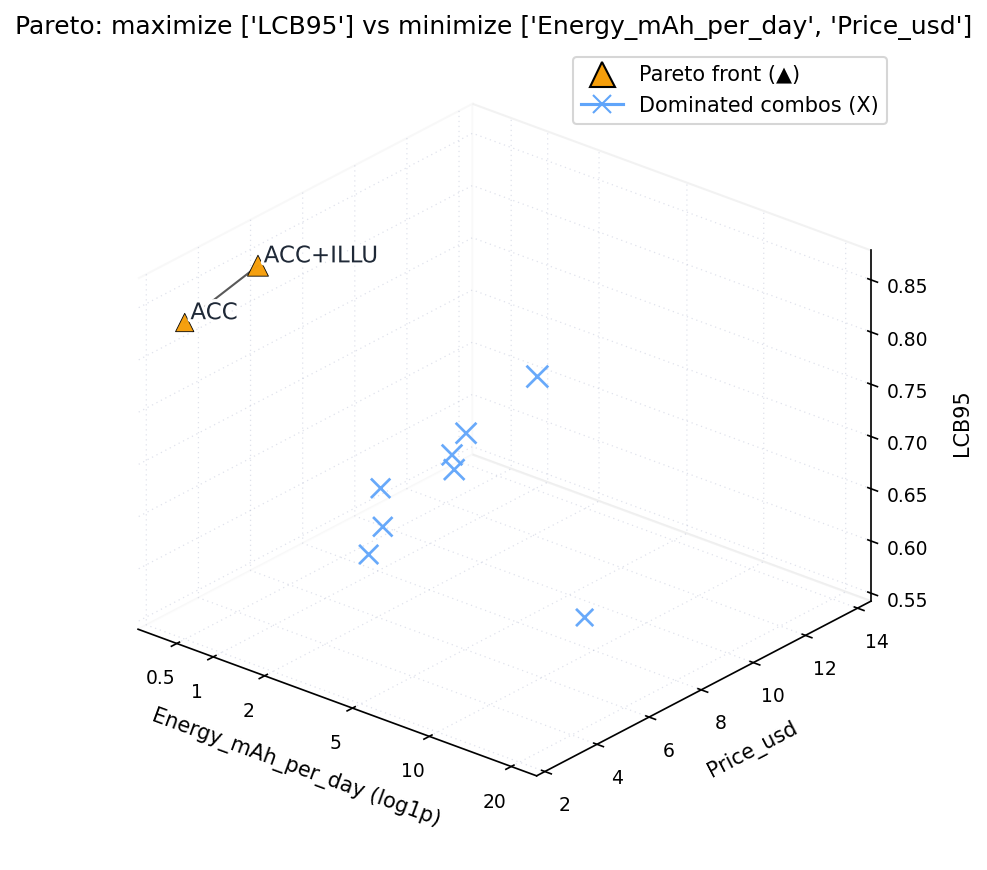

(<Figure size 1350x1050 with 1 Axes>,
 <Axes3D: title={'center': "Pareto: maximize ['LCB95'] vs minimize ['Energy_mAh_per_day', 'Price_usd']"}, xlabel='Energy_mAh_per_day (log1p)', ylabel='Price_usd', zlabel='LCB95'>,
   combo_id             sensors  Energy_mAh_per_day  Mass_g  Price_usd  \
 0        1                GYRO              20.000   0.098        4.5   
 1        2  MAG+PRES+TEMP+ILLU               1.181   0.113       13.7   
 2        3       MAG+TEMP+ILLU               1.104   0.098       10.6   
 3        4       MAG+PRES+ILLU               1.097   0.101       10.7   
 4        5       MAG+PRES+TEMP               1.121   0.105       11.1   
 5        6            MAG+ILLU               1.020   0.086        7.6   
 6        7            MAG+TEMP               1.044   0.090        8.0   
 7        8            MAG+PRES               1.037   0.093        8.1   
 8        9            ACC+ILLU               0.410   0.143        5.1   
 9       10                 ACC           

In [108]:

plot_pareto_auto(
    res_df,
    minimize=("Energy_mAh_per_day", "Price_usd"),
    maximize=("LCB95",),
    label_col="sensors",
    marker_size_col="Price_usd",
    log1p_cols=("Energy_mAh_per_day", "Mass_g")
)
# "energy_mAh_per_day", "mass_g", "price_usd", "volume_mm3"

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -----------------------------
# 小工具
# -----------------------------
def tf_log1p10(x):
    """log10(1+x)，对负值自动裁剪到0。"""
    x = np.asarray(x, dtype=float)
    return np.log10(1.0 + np.clip(x, a_min=0.0, a_max=None))

def nice_log1p_ticks(raw, k=6, min_gap=0.10):
    """
    为 log1p 轴返回漂亮刻度（以原始值显示），k≈刻度数量上限。
    简化实现：在原值[min,max]上取几何序列+边界。
    """
    raw = np.asarray(raw, dtype=float)
    raw = raw[np.isfinite(raw)]
    if raw.size == 0:
        return np.array([0.0, 1.0, 10.0])
    vmin, vmax = raw.min(), raw.max()
    if vmax <= 0:
        return np.unique(np.linspace(0, max(1.0, vmax+1), num=min(k, 5)))
    # 在 log1p 空间等距采样，再还原为原值显示
    tmin, tmax = tf_log1p10(vmin), tf_log1p10(vmax)
    ts = np.linspace(tmin, tmax, num=k)
    vals = (10**ts - 1.0)
    # 去重 & 最小间隔
    out = [vals[0]]
    for v in vals[1:]:
        if (tf_log1p10(v) - tf_log1p10(out[-1])) >= min_gap:
            out.append(v)
    return np.array(out, dtype=float)

def _annotate_points(ax, X, labels, idxs, color="#1f2937", fs=10, xy_off=(4,4)):
    """2D/3D 通用文字标注。"""
    is3d = hasattr(ax, "zaxis")
    for i in idxs:
        if is3d:
            ax.text(X[i,0], X[i,1], X[i,2], " " + str(labels[i]),
                    fontsize=fs, color=color, zorder=10)
        else:
            ax.annotate(str(labels[i]), (X[i,0], X[i,1]),
                        textcoords="offset points", xytext=xy_off,
                        ha="left", va="bottom", fontsize=fs, color=color)

def pareto_front(df, minimize=(), maximize=()):
    """
    计算混合“最小化/最大化”目标的帕累托前沿。
    若目标总数为1：返回该维的极值点（min 或 max，可有多个并列）。
    返回：bool 数组 ParetoFront
    """
    # 准备目标矩阵：统一转为“最小化”问题（最大化列取负号）
    cols = list(minimize) + list(maximize)
    if len(cols) == 0:
        raise ValueError("Pareto 计算至少需要 1 个目标（minimize 或 maximize）。")

    X = []
    for c in minimize:
        if c not in df.columns:
            raise ValueError(f"缺少列: {c}")
        X.append(df[c].to_numpy(dtype=float))
    for c in maximize:
        if c not in df.columns:
            raise ValueError(f"缺少列: {c}")
        X.append(-df[c].to_numpy(dtype=float))  # 最大化→取负成为最小化
    X = np.column_stack(X)  # [n, d]
    n, d = X.shape

    # 1 维退化：取极值（可能多点并列）
    if d == 1:
        v = X[:, 0]
        best = np.nanmin(v)  # 统一“最小化”
        mask = np.isclose(v, best, atol=1e-12) | (v == best)
        return mask

    # 一般情形：O(n^2) 判定（n 通常不大，便于阅读）
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        if dominated[i]:
            continue
        xi = X[i]
        # j 支配 i 条件：xj <= xi 且 任意一维严格小于
        for j in range(n):
            if i == j:
                continue
            xj = X[j]
            if np.all(xj <= xi) and np.any(xj < xi):
                dominated[i] = True
                break
    return ~dominated

# -----------------------------
# 自适应 2D/3D Pareto 绘图（最多 4 维展示：X/Y/Z + size）
# -----------------------------
def plot_pareto_auto(
    df: pd.DataFrame,
    minimize=(),
    maximize=(),
    label_col=None,             # 标注文字来源；None 用索引
    marker_size_col=None,       # 旧：点大小来源（备选）
    size_dim=None,              # 新：当维度≥4时，用哪一维映射为点大小
    extra_axis=None,            # **当目标总数 d==1 时，指定一个额外列作为 2D 的第二轴（仅可视化，不参与 Pareto）**
    log1p_cols=(),              # 对这些列做 log1p 压缩（坐标 & size 都会生效）
    view_elev=26, view_azim=-50,
    dpi=150,
    annotate_front=True,
    front_annot_k=None,         # None=标全部前沿；int=只标前K（按第1可视轴排序）
    size_min=18, size_max=180,
    size_clip_quant=(0.02, 0.98),
    size_sqrt=True,
    view_mode="auto",           # "auto" | "2d" | "3d"
    title=None,                 # 默认无标题
    legend_loc="upper left",
    legend_bbox=(1.02, 0.98),   # 轴外右上（不重叠）
):
    # ---------- 校验与准备 ----------
    dims = list(minimize) + list(maximize)
    d = len(dims)
    if d == 0:
        raise ValueError("至少提供 1 个目标（minimize 或 maximize）。")
    for c in dims:
        if c not in df.columns:
            raise ValueError(f"缺少列: {c}")
    df = df.copy()

    # ---------- Pareto 前沿 ----------
    if "ParetoFront" not in df.columns:
        df["ParetoFront"] = pareto_front(df, minimize=minimize, maximize=maximize)
    is_front = df["ParetoFront"].to_numpy()

    # ---------- 选取 size 源 ----------
    log1p_set = set(log1p_cols)
    size_src = None
    size_src_name = None
    # 若 d==4 且未指定 size_dim -> 默认最后一维做 size
    if size_dim is None and d == 4:
        size_dim = dims[-1]
    if size_dim is not None:
        if size_dim not in df.columns:
            raise ValueError(f"size_dim 未找到列: {size_dim}")
        size_src_name = size_dim
        size_src = df[size_dim].to_numpy(dtype=float)
    elif marker_size_col is not None and marker_size_col in df.columns:
        size_src_name = marker_size_col
        size_src = df[marker_size_col].to_numpy(dtype=float)

    # ---------- 构造可视化坐标 ----------
    # 坐标维度 = dims 去掉 size_dim；若 d==1，还需用 extra_axis 补一维以 2D 作图
    coord_dims = [c for c in dims if c != size_dim]
    if len(coord_dims) == 1:
        # 只有 1 个目标，用 extra_axis（不影响帕累托）
        if extra_axis is None:
            raise ValueError("仅 1 个目标时，请提供 extra_axis 作为第二个可视化维度。")
        if extra_axis not in df.columns:
            raise ValueError(f"extra_axis 未找到列: {extra_axis}")
        coord_dims = coord_dims + [extra_axis]

    # 可视化压缩（对命中 log1p_cols 的列做 log1p）
    raw_cols = [df[c].to_numpy(dtype=float) for c in coord_dims]
    trans_cols = [tf_log1p10(v) if c in log1p_set else v.copy()
                  for c, v in zip(coord_dims, raw_cols)]
    X_all = np.column_stack(trans_cols)
    d_coord = X_all.shape[1]

    # 自适应/强制维度
    use_pca = (d_coord > 3)
    if not use_pca:
        X_plot = X_all[:, :min(3, d_coord)]
        axis_names = coord_dims[:min(3, d_coord)]
    else:
        # PCA→3D
        Zm = X_all - X_all.mean(axis=0, keepdims=True)
        std = X_all.std(axis=0, keepdims=True); std[std == 0] = 1.0
        U, S, Vt = np.linalg.svd(Zm / std, full_matrices=False)
        X_plot = U[:, :3] * S[:3]
        axis_names = ["PC1","PC2","PC3"]

    if view_mode == "2d" and X_plot.shape[1] >= 2:
        X_plot = X_plot[:, :2]; axis_names = axis_names[:2]
    elif view_mode == "3d":
        if X_plot.shape[1] > 3:
            X_plot = X_plot[:, :3]; axis_names = axis_names[:3]
        # 若只有 2 维就保持 2D（无法强行生造第 3 维）

    n, k = X_plot.shape

    # ---------- 点大小映射 ----------
    if size_src is not None:
        v = size_src.copy()
        if size_src_name in log1p_set:
            v = tf_log1p10(np.clip(v, 0, None))
        ql, qh = np.quantile(v, size_clip_quant)
        v = np.clip(v, ql, qh)
        vmin, vmax = v.min(), v.max()
        vnorm = np.zeros_like(v) if vmax - vmin < 1e-12 else (v - vmin) / (vmax - vmin)
        if size_sqrt:
            vnorm = np.sqrt(vnorm)
        base_size = size_min + vnorm * (size_max - size_min)
        size_dom = base_size * 0.8
        size_fr  = base_size * 1.1
    else:
        size_dom = np.full(n, max(size_min, 36.0))
        size_fr  = np.full(n, max(size_min * 1.2, 64.0))

    labels = (
        df[label_col].astype(str).to_numpy()
        if (label_col and label_col in df.columns) else df.index.to_numpy()
    )

    # ---------- 样式 ----------
    C_DOM = "#60a5fa"   # 冷蓝（被支配）
    C_FR  = "#f59e0b"   # 暖橙（前沿）

    # ---------- 绘图 ----------
    fig = plt.figure(figsize=(9, 7), dpi=dpi)

    if k == 3:
        ax = fig.add_subplot(111, projection='3d')
        ax.set_proj_type('ortho')
        ax.view_init(elev=view_elev, azim=view_azim)
        for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
            pane.set_facecolor((1, 1, 1, 0.95))
        for axinfo in (ax.xaxis._axinfo, ax.yaxis._axinfo, ax.zaxis._axinfo):
            axinfo["grid"]['linestyle'] = (0, (1, 3))
            axinfo["grid"]['linewidth'] = 0.6
            axinfo["grid"]['color']     = (0.5, 0.55, 0.7, 0.25)
        ax.grid(True, linewidth=0.6, alpha=0.18)

        ax.scatter(X_plot[~is_front,0], X_plot[~is_front,1], X_plot[~is_front,2],
                   s=size_dom[~is_front], c=C_DOM, marker='x', linewidths=1.3, alpha=0.95,
                   label="Dominated combos (X)")
        ax.scatter(X_plot[ is_front,0], X_plot[ is_front,1], X_plot[ is_front,2],
                   s=size_fr[ is_front], c=C_FR, marker='^', edgecolor='k', linewidths=0.4, alpha=0.98,
                   label="Pareto front (▲)")

        idx_fr = np.where(is_front)[0]
        sorter = idx_fr[np.argsort(X_plot[idx_fr, 0])]
        if len(sorter) > 1:
            ax.plot(X_plot[sorter,0], X_plot[sorter,1], X_plot[sorter,2],
                    color='k', lw=1.0, alpha=0.65)

        if annotate_front and len(sorter) > 0:
            use_idx = sorter[:front_annot_k] if isinstance(front_annot_k, int) else sorter
            _annotate_points(ax, X_plot, labels, use_idx, color="#1f2937", fs=11, xy_off=(4,4))

        # 轴标签（仅当不是 PCA 且命中 log1p 时追加说明 & 原刻度）
        ax.set_xlabel(axis_names[0] + (" (log1p)" if (axis_names[0] in log1p_set and not use_pca) else ""))
        ax.set_ylabel(axis_names[1] + (" (log1p)" if (axis_names[1] in log1p_set and not use_pca) else ""))
        ax.set_zlabel(axis_names[2] + (" (log1p)" if (axis_names[2] in log1p_set and not use_pca) else ""))

        if not use_pca:
            for col_idx in (0,1,2):
                col_name = axis_names[col_idx]
                if col_name in log1p_set:
                    raw_vals = df[col_name].to_numpy(dtype=float)
                    ticks_raw = nice_log1p_ticks(raw_vals, k=6, min_gap=0.10)
                    if col_idx == 0:
                        ax.set_xticks(tf_log1p10(ticks_raw)); ax.set_xticklabels([f"{v:g}" for v in ticks_raw])
                    elif col_idx == 1:
                        ax.set_yticks(tf_log1p10(ticks_raw)); ax.set_yticklabels([f"{v:g}" for v in ticks_raw])
                    else:
                        ax.set_zticks(tf_log1p10(ticks_raw)); ax.set_zticklabels([f"{v:g}" for v in ticks_raw])

        ax.tick_params(axis='x', labelsize=9, pad=2)
        ax.tick_params(axis='y', labelsize=9, pad=2)
        ax.tick_params(axis='z', labelsize=9, pad=2)

    else:  # 2D 视图
        ax = fig.add_subplot(111)
        ax.grid(True, linewidth=0.6, alpha=0.25, linestyle=(0, (1, 3)))

        ax.scatter(X_plot[~is_front,0], X_plot[~is_front,1],
                   s=size_dom[~is_front], c=C_DOM, marker='x', linewidths=1.3, alpha=0.95,
                   label="Dominated combos (X)")
        ax.scatter(X_plot[ is_front,0], X_plot[ is_front,1],
                   s=size_fr[ is_front], c=C_FR, marker='^', edgecolor='k', linewidths=0.4, alpha=0.98,
                   label="Pareto front (▲)")

        idx_fr = np.where(is_front)[0]
        sorter = idx_fr[np.argsort(X_plot[idx_fr, 0])]
        if len(sorter) > 1:
            ax.plot(X_plot[sorter,0], X_plot[sorter,1],
                    color='k', lw=1.0, alpha=0.65)

        if annotate_front and len(sorter) > 0:
            use_idx = sorter[:front_annot_k] if isinstance(front_annot_k, int) else sorter
            _annotate_points(ax, X_plot, labels, use_idx, color="#1f2937", fs=11, xy_off=(4,4))

        ax.set_xlabel(axis_names[0] + (" (log1p)" if (axis_names[0] in log1p_set and not use_pca) else ""))
        ax.set_ylabel(axis_names[1] + (" (log1p)" if (axis_names[1] in log1p_set and not use_pca) else ""))

        if not use_pca:
            for col_idx in (0,1):
                col_name = axis_names[col_idx]
                if col_name in log1p_set:
                    raw_vals = df[col_name].to_numpy(dtype=float)
                    ticks_raw = nice_log1p_ticks(raw_vals, k=6, min_gap=0.10)
                    if col_idx == 0:
                        ax.set_xticks(tf_log1p10(ticks_raw)); ax.set_xticklabels([f"{v:g}" for v in ticks_raw])
                    else:
                        ax.set_yticks(tf_log1p10(ticks_raw)); ax.set_yticklabels([f"{v:g}" for v in ticks_raw])

        ax.tick_params(axis='both', labelsize=9, pad=2)

    # ---------- 标题 & 图例 ----------
    if isinstance(title, str):
        ax.set_title(title)

    legend_handles = [
        Line2D([0],[0], marker="^", color="w", label="Pareto front (▲)",
               markerfacecolor="#f59e0b", markeredgecolor="k", markersize=12, linewidth=0.0),
        Line2D([0],[0], marker="x", color="#60a5fa", label="Dominated combos (X)",
               markersize=9, linewidth=1.5),
    ]
    ax.legend(handles=legend_handles, loc=legend_loc, bbox_to_anchor=legend_bbox,
              frameon=True, borderaxespad=0.6)

    fig.tight_layout()
    plt.show()
    return fig, ax, df


C:\Users\dell\AppData\Local\Temp\ipykernel_23732\2682909549.py:321: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


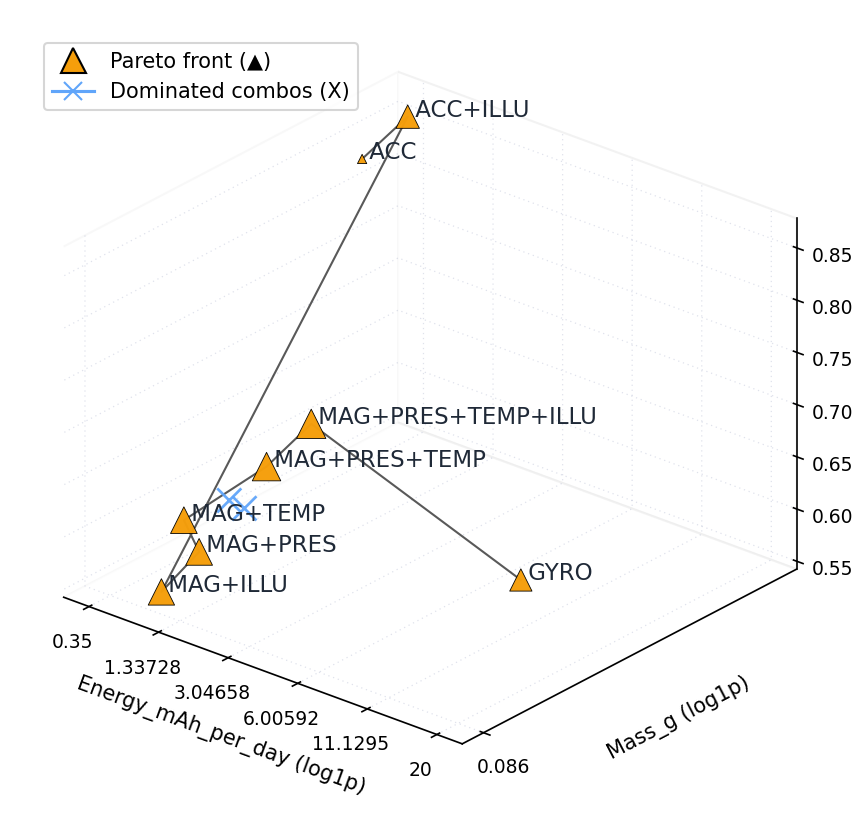

In [123]:

# plot_pareto_auto(
#     res_df,
#     minimize=("Energy_mAh_per_day", "Mass_g", "Price_usd"),
#     maximize=("LCB95",),
#     label_col="sensors",
#     marker_size_col="Price_usd",
#     log1p_cols=("Energy_mAh_per_day", "Mass_g")
# )
fig, ax, _ = plot_pareto_auto(
    res_df,
    minimize=("Energy_mAh_per_day","Mass_g"),
    maximize=("LCB95",),
    size_dim="Price_usd",
    log1p_cols=("Energy_mAh_per_day","Mass_g","Price_usd"),
    label_col="sensors",            # ← 贴传感器名字
    annotate_front=True,
    front_annot_k=None,             # ← 标全部前沿
    title=None,                     # ← 不要标题
    legend_loc="upper left",        # ← 轴外
    legend_bbox=(0.02, 0.98),
)



C:\Users\dell\AppData\Local\Temp\ipykernel_23732\2682909549.py:321: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


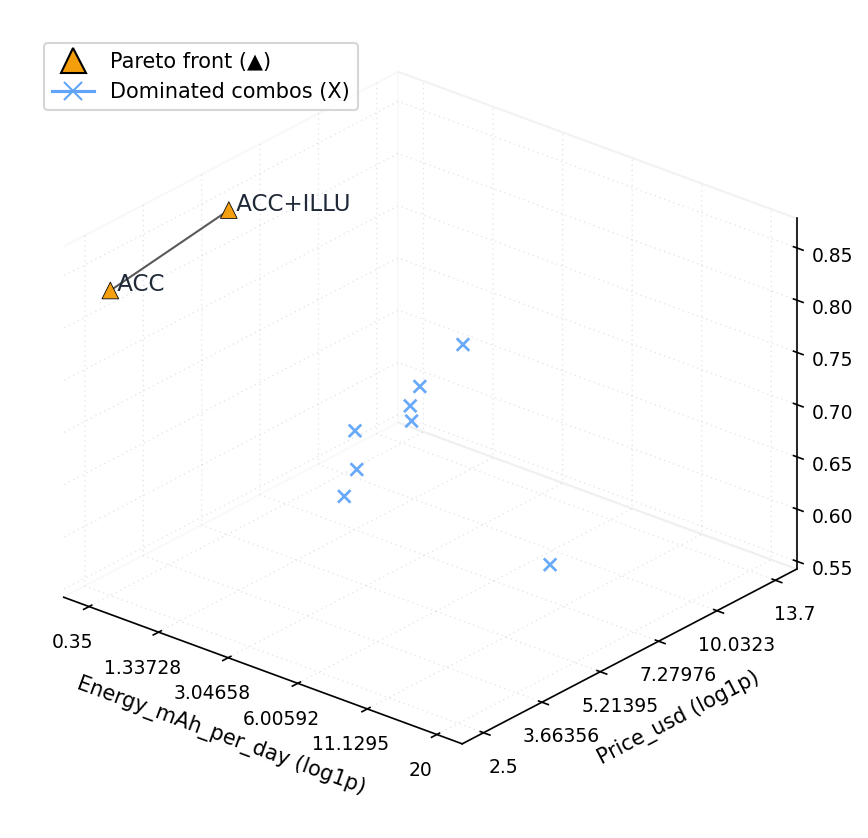

In [124]:
fig, ax, _ = plot_pareto_auto(
    res_df,
    minimize=("Energy_mAh_per_day","Price_usd"),
    maximize=("LCB95",),
    size_dim=None,
    log1p_cols=("Energy_mAh_per_day","Mass_g","Price_usd"),
    label_col="sensors",            # ← 贴传感器名字
    annotate_front=True,
    front_annot_k=None,             # ← 标全部前沿
    title=None,                     # ← 不要标题
    legend_loc="upper left",        # ← 轴外
    legend_bbox=(0.02, 0.98),
)

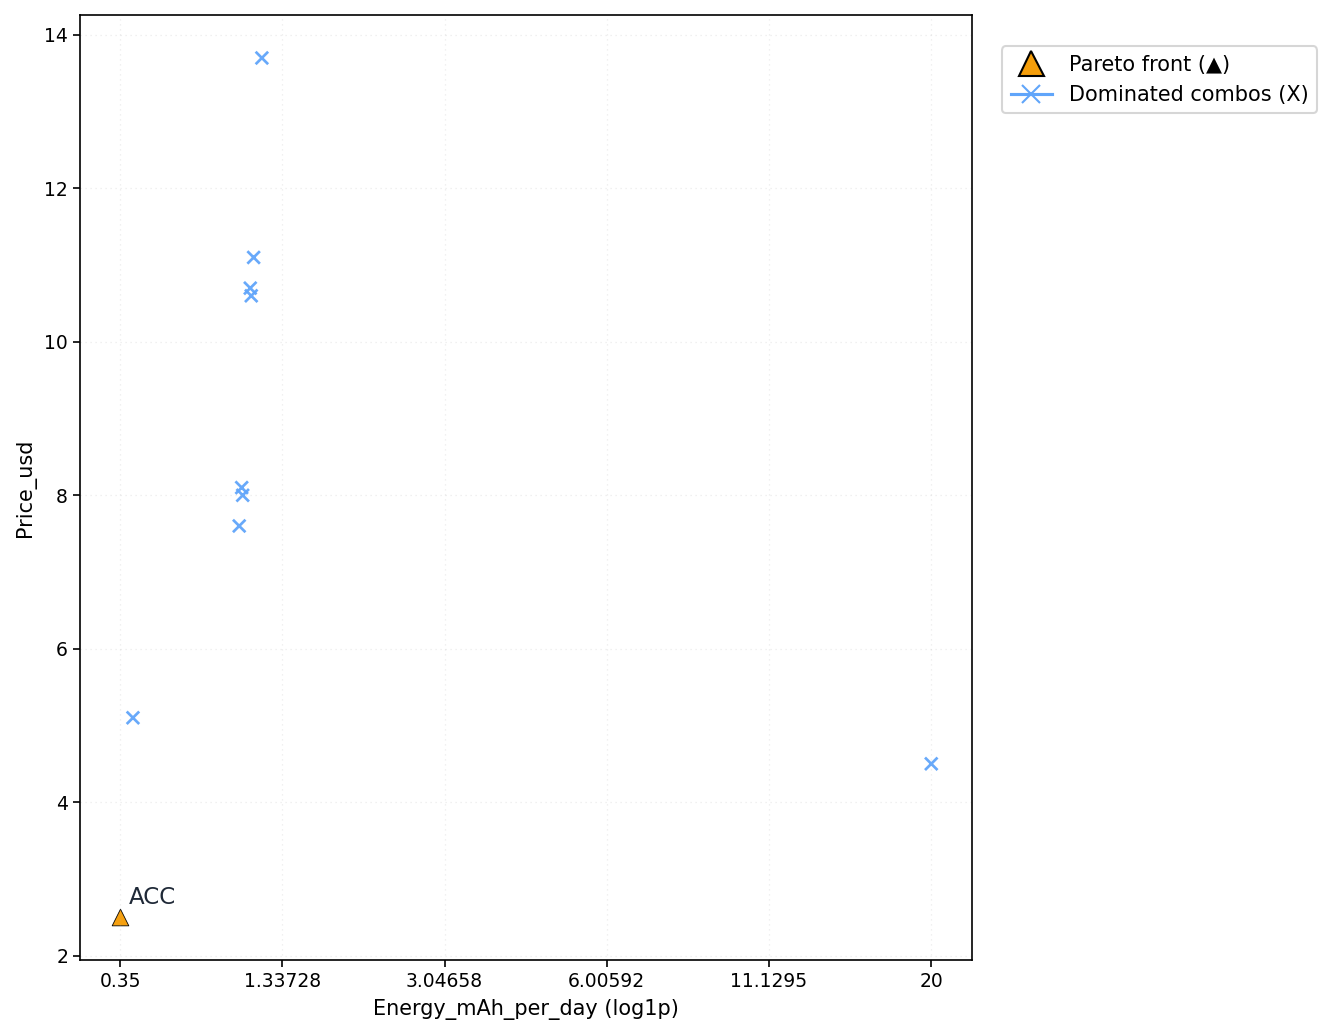

(<Figure size 1350x1050 with 1 Axes>,
 <Axes: xlabel='Energy_mAh_per_day (log1p)', ylabel='Price_usd'>,
   combo_id             sensors  Energy_mAh_per_day  Mass_g  Price_usd  \
 0        1                GYRO              20.000   0.098        4.5   
 1        2  MAG+PRES+TEMP+ILLU               1.181   0.113       13.7   
 2        3       MAG+TEMP+ILLU               1.104   0.098       10.6   
 3        4       MAG+PRES+ILLU               1.097   0.101       10.7   
 4        5       MAG+PRES+TEMP               1.121   0.105       11.1   
 5        6            MAG+ILLU               1.020   0.086        7.6   
 6        7            MAG+TEMP               1.044   0.090        8.0   
 7        8            MAG+PRES               1.037   0.093        8.1   
 8        9            ACC+ILLU               0.410   0.143        5.1   
 9       10                 ACC               0.350   0.135        2.5   
 
    Volume_mm3      Fbar       Std     LCB95  ParetoFront  
 0         6.0  0.71

In [127]:
plot_pareto_auto(
    res_df,
    minimize=("Energy_mAh_per_day","Price_usd"),
    maximize=(),
    label_col="sensors",
    log1p_cols=("Energy_mAh_per_day",),
    view_mode="2d",
)

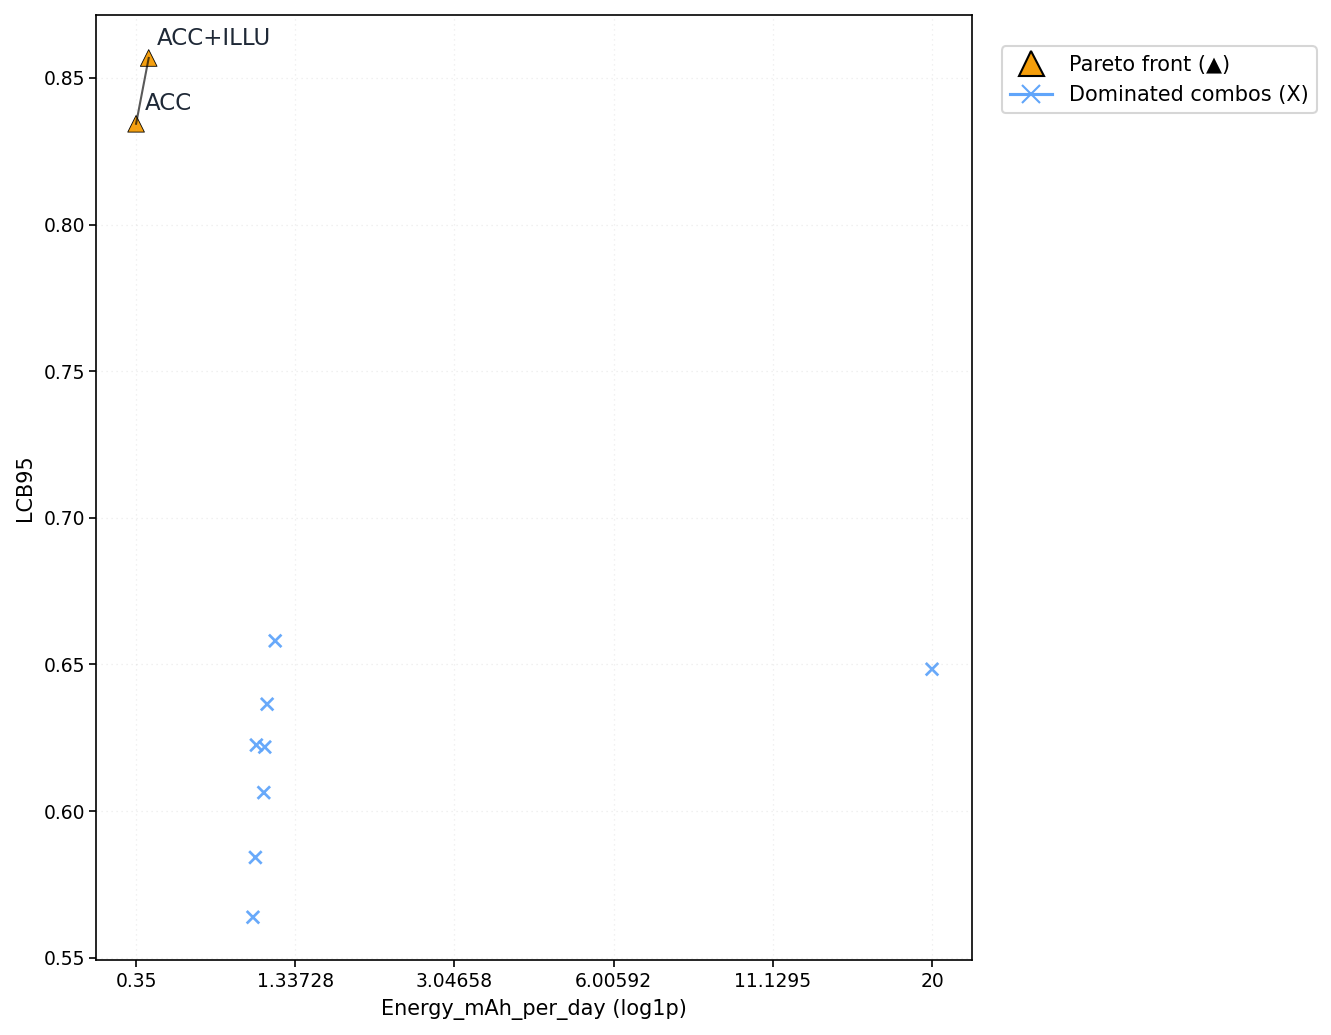

(<Figure size 1350x1050 with 1 Axes>,
 <Axes: xlabel='Energy_mAh_per_day (log1p)', ylabel='LCB95'>,
   combo_id             sensors  Energy_mAh_per_day  Mass_g  Price_usd  \
 0        1                GYRO              20.000   0.098        4.5   
 1        2  MAG+PRES+TEMP+ILLU               1.181   0.113       13.7   
 2        3       MAG+TEMP+ILLU               1.104   0.098       10.6   
 3        4       MAG+PRES+ILLU               1.097   0.101       10.7   
 4        5       MAG+PRES+TEMP               1.121   0.105       11.1   
 5        6            MAG+ILLU               1.020   0.086        7.6   
 6        7            MAG+TEMP               1.044   0.090        8.0   
 7        8            MAG+PRES               1.037   0.093        8.1   
 8        9            ACC+ILLU               0.410   0.143        5.1   
 9       10                 ACC               0.350   0.135        2.5   
 
    Volume_mm3      Fbar       Std     LCB95  ParetoFront  
 0         6.0  0.712203

In [126]:
plot_pareto_auto(
    res_df,
    minimize=("Energy_mAh_per_day",),
    maximize=("LCB95",),
    label_col="sensors",
    log1p_cols=("Energy_mAh_per_day",),
    view_mode="2d",
)